In [11]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


In [31]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

rf_df    = pd.read_csv(data_dir / "ophys_rf_centers.csv")
units_df = pd.read_csv(data_dir / "none" / "unit_info.csv")

df = units_df.merge(rf_df, left_on='unit_id', right_on='roi_id', how='left')

print(df.shape)
print(df[['unit_id', 'mouse', 'plane', 'gmm_label', 'rf_center_x', 'rf_center_y', 'rf_r_squared']].head())
print(f"\nUnits with valid RF: {df['rf_center_x'].notna().sum()} / {len(df)}")

df.to_csv(data_dir / "unit_info_with_rf.csv", index=False)
print("Saved unit_info_with_rf.csv")

(6184, 8)
                     unit_id       mouse   plane  gmm_label  rf_center_x  \
0    sub-809092__VISp_0_roi0  sub-809092  VISp_0          2   -40.000000   
1    sub-809092__VISp_0_roi1  sub-809092  VISp_0          2    12.104379   
2   sub-809092__VISp_0_roi10  sub-809092  VISp_0         10   -40.000000   
3  sub-809092__VISp_0_roi100  sub-809092  VISp_0          2    13.643322   
4  sub-809092__VISp_0_roi101  sub-809092  VISp_0         28   -30.627505   

   rf_center_y  rf_r_squared  
0    -8.615651      0.191937  
1   -40.000000      0.059264  
2    40.000000      0.078988  
3    34.137125      0.115083  
4   -40.000000      0.183437  

Units with valid RF: 6184 / 6184
Saved unit_info_with_rf.csv


In [16]:
# find matches between unit_id and roi_id and return number of matches
matched_df = pd.merge(units_df, rf_df, left_on='unit_id', right_on='roi_id')
print(matched_df.shape)

(6184, 8)


In [14]:
response_matrix = np.load(data_dir / "none"/ "response_matrix.npy")
print(response_matrix.shape)

response_norm = normalize(response_matrix, norm='l2')

pca   = PCA()
X_pca = pca.fit_transform(response_norm)

explained = np.cumsum(pca.explained_variance_ratio_)
n_pcs     = np.searchsorted(explained, 0.90) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

X_pca = X_pca[:, :n_pcs]

(6184, 100)
PCs needed for 90% variance: 77


## Pairwise distances

In [20]:
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

In [28]:
MAX_UNITS = matched_df.shape[0]  # Set to a smaller number if you want to subsample
if len(matched_df) > MAX_UNITS:
    idx   = np.random.choice(len(matched_df), MAX_UNITS, replace=False)
    df_s  = matched_df.iloc[idx].reset_index(drop=True)
    X_s   = X_pca[idx]
    print(f"Subsampled to {MAX_UNITS} units")
else:
    df_s, X_s = matched_df, X_pca

retino_coords = df_s[['rf_center_x', 'rf_center_y']].values
latent_dists  = pairwise_distances(X_s,            metric='euclidean')   # (N, N)
retino_dists  = pairwise_distances(retino_coords,  metric='euclidean')   # (N, N)

# ── Extract upper triangle (avoid duplicates + self-pairs) ───────────────────
triu          = np.triu_indices(len(df_s), k=1)
lat_flat      = latent_dists[triu]
ret_flat      = retino_dists[triu]

# ── Bin by retinotopic distance and plot mean latent distance ─────────────────
n_bins  = 30
bins    = np.percentile(ret_flat, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(ret_flat, bins) - 1
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

In [29]:
bin_centers  = []
mean_latent  = []
sem_latent   = []

for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() < 10:
        continue
    vals = lat_flat[mask]
    bin_centers.append((bins[b] + bins[b+1]) / 2)
    mean_latent.append(vals.mean())
    sem_latent.append(vals.std() / np.sqrt(len(vals)))

bin_centers = np.array(bin_centers)
mean_latent = np.array(mean_latent)
sem_latent  = np.array(sem_latent)

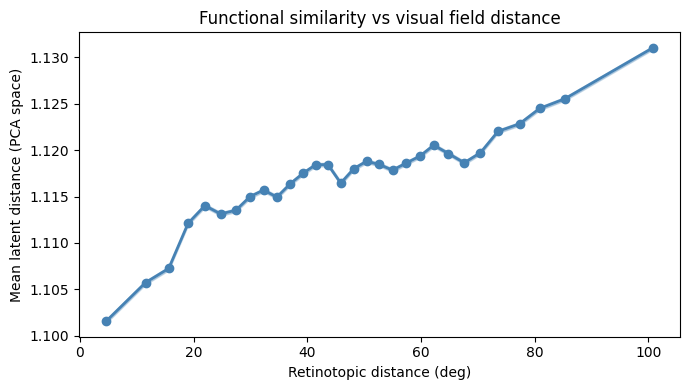

Done


In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bin_centers, mean_latent, 'o-', color='steelblue', lw=2)
ax.fill_between(bin_centers,
                mean_latent - sem_latent,
                mean_latent + sem_latent,
                alpha=0.3, color='steelblue')
ax.set_xlabel("Retinotopic distance (deg)")
ax.set_ylabel("Mean latent distance (PCA space)")
ax.set_title("Functional similarity vs visual field distance")
plt.tight_layout()
plt.savefig(data_dir / "latent_vs_retino_distance.png", dpi=150)
plt.show()

print("Done")

  Shuffle 1/20 done
  Shuffle 2/20 done
  Shuffle 3/20 done
  Shuffle 4/20 done
  Shuffle 5/20 done
  Shuffle 6/20 done
  Shuffle 7/20 done
  Shuffle 8/20 done
  Shuffle 9/20 done
  Shuffle 10/20 done
  Shuffle 11/20 done
  Shuffle 12/20 done
  Shuffle 13/20 done
  Shuffle 14/20 done
  Shuffle 15/20 done
  Shuffle 16/20 done
  Shuffle 17/20 done
  Shuffle 18/20 done
  Shuffle 19/20 done
  Shuffle 20/20 done


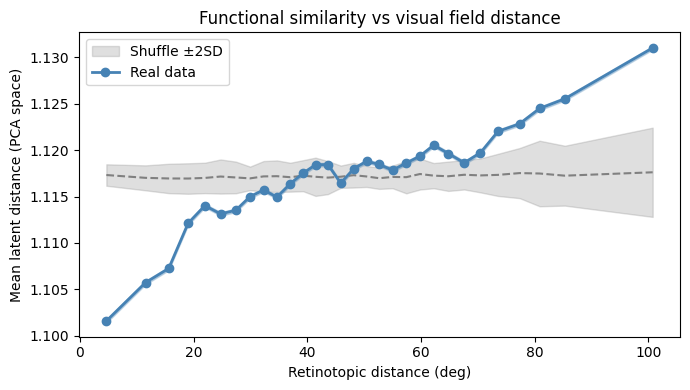

In [22]:
# ── Shuffle control ───────────────────────────────────────────────────────────
N_SHUFFLES = 20

shuffle_curves = []

for i in range(N_SHUFFLES):
    # Shuffle the PCA coordinates across neurons
    shuf_idx  = np.random.permutation(len(X_s))
    X_shuf    = X_s[shuf_idx]
    
    lat_shuf  = pairwise_distances(X_shuf, metric='euclidean')
    lat_shuf  = lat_shuf[triu]
    
    curve = []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() < 10:
            curve.append(np.nan)
        else:
            curve.append(lat_shuf[mask].mean())
    shuffle_curves.append(curve)
    print(f"  Shuffle {i+1}/{N_SHUFFLES} done")

shuffle_curves = np.array(shuffle_curves)           # (N_SHUFFLES, n_bins)
shuf_mean      = np.nanmean(shuffle_curves, axis=0)
shuf_std       = np.nanstd(shuffle_curves,  axis=0)

# ── Plot real vs shuffle ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

# Shuffle
ax.fill_between(bin_centers,
                shuf_mean - 2*shuf_std,
                shuf_mean + 2*shuf_std,
                alpha=0.25, color='gray', label='Shuffle ±2SD')
ax.plot(bin_centers, shuf_mean, '--', color='gray', lw=1.5)

# Real
ax.plot(bin_centers, mean_latent, 'o-', color='steelblue', lw=2, label='Real data')
ax.fill_between(bin_centers,
                mean_latent - sem_latent,
                mean_latent + sem_latent,
                alpha=0.3, color='steelblue')

ax.set_xlabel("Retinotopic distance (deg)")
ax.set_ylabel("Mean latent distance (PCA space)")
ax.set_title("Functional similarity vs visual field distance")
ax.legend()
plt.tight_layout()
plt.savefig(data_dir / "latent_vs_retino_distance_with_shuffle.png", dpi=150)
plt.show()

## Check against regression

In [69]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [70]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

Neurons with valid RF: 6184
Unique SFs:  [0.02 0.04 0.08 0.16 0.32]
Unique TFs:  [ 1.  2.  4.  8. 15.]
Unique Oris: [  0.  45.  90. 135.]


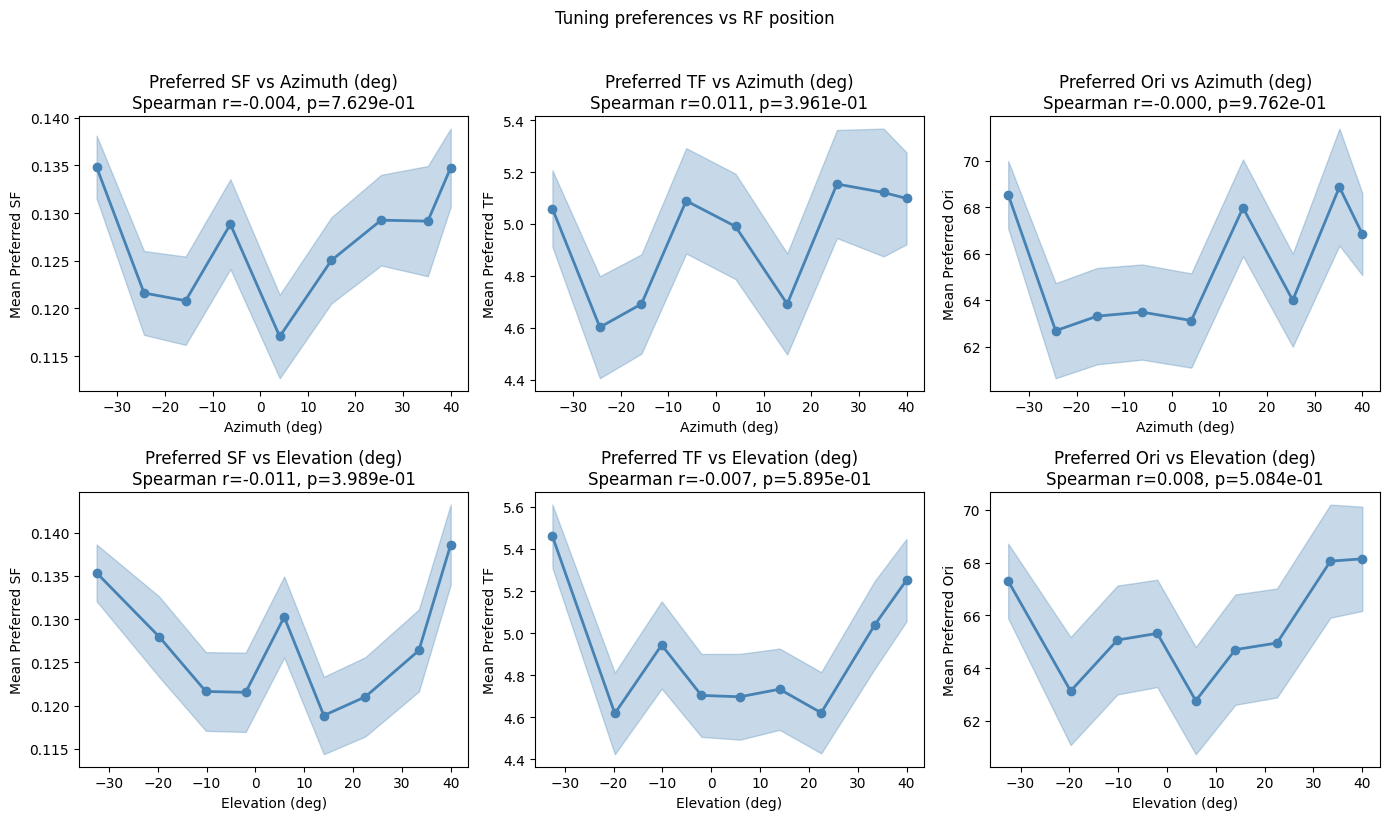

In [71]:
# ── Load ──────────────────────────────────────────────────────────────────────
df              = pd.read_csv(data_dir / "unit_info_with_rf.csv")
response_matrix = np.load(data_dir / "none" / "response_matrix.npy")
sc              = pd.read_csv(data_dir / "none" / "stimulus_conditions.csv")

# ── Filter to valid RF neurons only ───────────────────────────────────────────
valid   = df['rf_center_x'].notna() & df['rf_center_y'].notna()
df_v    = df[valid].reset_index(drop=True)
resp_v  = response_matrix[valid.values]

print(f"Neurons with valid RF: {len(df_v)}")

# ── Get preferred SF, TF, ori per neuron (argmax) ─────────────────────────────
# response_matrix columns correspond to stimulus_condition_id 0..99
sfs  = sc['spatial_frequency'].values    # (100,)
tfs  = sc['temporal_frequency'].values   # (100,)
oris = sc['orientation'].values          # (100,)

# For each neuron, find the condition with max response
best_cond   = np.argmax(resp_v, axis=1)  # (n_neurons,)

pref_sf  = sfs[best_cond]
pref_tf  = tfs[best_cond]
pref_ori = oris[best_cond]

print(f"Unique SFs:  {np.unique(pref_sf)}")
print(f"Unique TFs:  {np.unique(pref_tf)}")
print(f"Unique Oris: {np.unique(pref_ori)}")

# ── Regress each tuning property against RF position ──────────────────────────
rf_x = df_v['rf_center_x'].values
rf_y = df_v['rf_center_y'].values   # elevation

tuning = {
    'Preferred SF':  pref_sf,
    'Preferred TF':  pref_tf,
    'Preferred Ori': pref_ori,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (name, pref) in enumerate(tuning.items()):
    for row, (pos, pos_name) in enumerate([(rf_x, 'Azimuth (deg)'), 
                                            (rf_y, 'Elevation (deg)')]):
        ax = axes[row, col]

        # Spearman correlation
        r, p = spearmanr(pos, pref)

        # Bin the position axis and plot mean preferred value per bin
        n_bins   = 10
        bins     = np.percentile(pos, np.linspace(0, 100, n_bins + 1))
        bin_idx  = np.digitize(pos, bins) - 1
        bin_idx  = np.clip(bin_idx, 0, n_bins - 1)

        bin_centers = []
        bin_means   = []
        bin_sems    = []

        for b in range(n_bins):
            mask = bin_idx == b
            if mask.sum() < 5:
                continue
            vals = pref[mask]
            bin_centers.append((bins[b] + bins[b+1]) / 2)
            bin_means.append(np.mean(vals))
            bin_sems.append(np.std(vals) / np.sqrt(len(vals)))

        bin_centers = np.array(bin_centers)
        bin_means   = np.array(bin_means)
        bin_sems    = np.array(bin_sems)

        ax.plot(bin_centers, bin_means, 'o-', color='steelblue', lw=2)
        ax.fill_between(bin_centers,
                        bin_means - bin_sems,
                        bin_means + bin_sems,
                        alpha=0.3, color='steelblue')
        ax.set_xlabel(pos_name)
        ax.set_ylabel(f"Mean {name}")
        ax.set_title(f"{name} vs {pos_name}\nSpearman r={r:.3f}, p={p:.3e}")

plt.suptitle("Tuning preferences vs RF position", y=1.02)
plt.tight_layout()
plt.savefig(data_dir / "tuning_vs_rf_position.png", dpi=150, bbox_inches='tight')
plt.show()

## Colored by latent space 

In [39]:
N_BINS  = 8
min_neurons = 10

PCs needed for 90% variance: 77
Optimal n_components: 29


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


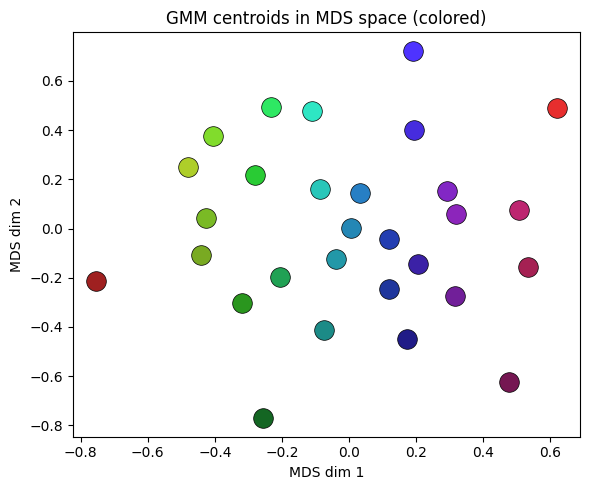

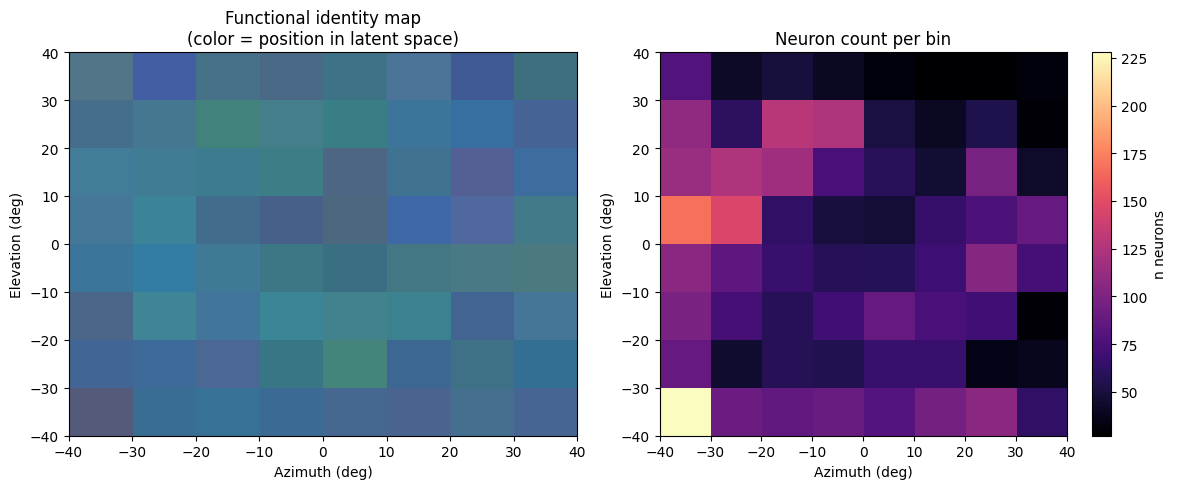

Done


In [50]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

# ── Load ──────────────────────────────────────────────────────────────────────
df              = pd.read_csv(data_dir / "unit_info_with_rf.csv")
response_matrix = np.load(data_dir /"none"/ "response_matrix.npy")

# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_matrix, norm='l2')

pca   = PCA()
X_pca = pca.fit_transform(response_norm)

explained = np.cumsum(pca.explained_variance_ratio_)
n_pcs     = np.searchsorted(explained, 0.90) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

X_pca = X_pca[:, :n_pcs]
# ── Refit GMM ─────────────────────────────────────────────────────────────────
response_norm = normalize(response_matrix, norm='l2')

n_range = range(2, 30)
bics    = []
for n in n_range:
    gmm_n = GaussianMixture(n_components=n, covariance_type='diag', random_state=0).fit(X_pca)
    bics.append(gmm_n.bic(X_pca))

optimal_n = list(n_range)[np.argmin(bics)]
print(f"Optimal n_components: {optimal_n}")

gmm    = GaussianMixture(n_components=optimal_n, covariance_type='full', random_state=0)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)
probs  = gmm.predict_proba(X_pca)   # (n_units, n_clusters) soft assignments

# ── Embed cluster centroids in 2D via MDS ─────────────────────────────────────
centroids  = gmm.means_                                        # (n_clusters, n_pcs)
mds        = MDS(n_components=2, dissimilarity='euclidean', random_state=0)
centroids_2d = mds.fit_transform(centroids)                    # (n_clusters, 2)

# Normalize to [0, 1] for colormap
cx = (centroids_2d[:, 0] - centroids_2d[:, 0].min()) / (centroids_2d[:, 0].ptp() + 1e-8)
cy = (centroids_2d[:, 1] - centroids_2d[:, 1].min()) / (centroids_2d[:, 1].ptp() + 1e-8)

# ── Map 2D centroid positions to HSV colors ────────────────────────────────────
# hue = x position in MDS space, value = y position
# this way similar clusters (close in latent space) get similar colors
cluster_colors = np.array([
    mcolors.hsv_to_rgb([cx[k], 0.8, 0.4 + 0.6 * cy[k]])
    for k in range(optimal_n)
])                                                             # (n_clusters, 3) RGB

# ── Project all neurons into MDS 2D space ─────────────────────────────────────
# MDS was fit on centroids — we approximate each neuron's 2D position
# by finding its weighted average of centroid positions using soft GMM posteriors
neuron_2d = probs @ centroids_2d        # (n_units, 2)  soft-weighted average

# Normalize to [0, 1]
nx = (neuron_2d[:, 0] - centroids_2d[:, 0].min()) / (centroids_2d[:, 0].ptp() + 1e-8)
ny = (neuron_2d[:, 1] - centroids_2d[:, 1].min()) / (centroids_2d[:, 1].ptp() + 1e-8)
nx = np.clip(nx, 0, 1)
ny = np.clip(ny, 0, 1)

# Assign HSV color per neuron individually
neuron_colors = np.array([
    mcolors.hsv_to_rgb([nx[i], 0.8, 0.4 + 0.6 * ny[i]])
    for i in range(len(nx))
])                                      # (n_units, 3)

# ── Plot latent space colored by cluster color ─────────────────────────────────
# Quick sanity check — does the colormap make sense?
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(optimal_n):
    mask = labels == k
    ax.scatter(centroids_2d[k, 0], centroids_2d[k, 1],
               color=cluster_colors[k], s=200, zorder=5, edgecolors='k', linewidths=0.5)
    ax.annotate(str(k), centroids_2d[k], fontsize=7, ha='center', va='center')
ax.set_title("GMM centroids in MDS space (colored)")
ax.set_xlabel("MDS dim 1")
ax.set_ylabel("MDS dim 2")
plt.tight_layout()
plt.savefig(data_dir / "gmm_centroids_mds.png", dpi=150)
plt.show()

# ── Build visual field map ─────────────────────────────────────────────────────
valid       = df['rf_center_x'].notna() & df['rf_center_y'].notna()
df_v        = df[valid].reset_index(drop=True)
colors_v    = neuron_colors[valid.values]


rf_x = df_v['rf_center_x'].values
rf_y = df_v['rf_center_y'].values

# Bin the visual field
N_BINS  = N_BINS
x_bins  = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins  = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

color_map   = np.full((N_BINS, N_BINS, 3), np.nan)
count_map   = np.zeros((N_BINS, N_BINS))

for i in range(N_BINS):
    for j in range(N_BINS):
        mask = (
            (rf_x >= x_bins[i])  & (rf_x < x_bins[i+1]) &
            (rf_y >= y_bins[j])  & (rf_y < y_bins[j+1])
        )
        if mask.sum() > 0:
            color_map[j, i]  = colors_v[mask].mean(axis=0)
            count_map[j, i]  = mask.sum()

# Mask bins with too few neurons
min_neurons = 10
color_map[count_map < min_neurons] = np.nan

# ── Plot visual field color map ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: color map
ax = axes[0]
# Replace nan bins with white for display
display_map = np.where(np.isnan(color_map), 1.0, color_map)
ax.imshow(display_map, origin='lower',
          extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
          aspect='auto')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Functional identity map\n(color = position in latent space)")

# Right: neuron count per bin
ax = axes[1]
im = ax.imshow(count_map, origin='lower',
               extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
               aspect='auto', cmap='magma')
plt.colorbar(im, ax=ax, label='n neurons')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Neuron count per bin")

plt.tight_layout()
plt.savefig(data_dir / "visual_field_functional_map.png", dpi=150)
plt.show()

print("Done")

In [41]:
# How dominant is the top cluster per neuron?
top_prob = probs.max(axis=1)
print(f"Mean max posterior probability: {top_prob.mean():.3f}")
print(f"Neurons with >0.9 confidence: {(top_prob > 0.9).sum()} / {len(top_prob)}")
print(f"Neurons with >0.5 confidence: {(top_prob > 0.5).sum()} / {len(top_prob)}")

Mean max posterior probability: 0.999
Neurons with >0.9 confidence: 6174 / 6184
Neurons with >0.5 confidence: 6184 / 6184


In [42]:
# How big is each cluster?
unique, counts = np.unique(labels, return_counts=True)
for k, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"Cluster {k:2d}: {c:4d} neurons ({100*c/len(labels):.1f}%)")

Cluster 13:  637 neurons (10.3%)
Cluster 25:  596 neurons (9.6%)
Cluster 10:  481 neurons (7.8%)
Cluster  1:  430 neurons (7.0%)
Cluster 11:  427 neurons (6.9%)
Cluster 26:  334 neurons (5.4%)
Cluster  2:  261 neurons (4.2%)
Cluster 18:  229 neurons (3.7%)
Cluster  3:  195 neurons (3.2%)
Cluster 19:  192 neurons (3.1%)
Cluster 28:  186 neurons (3.0%)
Cluster 15:  167 neurons (2.7%)
Cluster  0:  155 neurons (2.5%)
Cluster 12:  155 neurons (2.5%)
Cluster 16:  148 neurons (2.4%)
Cluster  4:  139 neurons (2.2%)
Cluster  6:  133 neurons (2.2%)
Cluster 20:  133 neurons (2.2%)
Cluster 14:  131 neurons (2.1%)
Cluster  9:  130 neurons (2.1%)
Cluster  5:  123 neurons (2.0%)
Cluster 21:  110 neurons (1.8%)
Cluster  8:  109 neurons (1.8%)
Cluster 22:  105 neurons (1.7%)
Cluster 24:  105 neurons (1.7%)
Cluster 27:  102 neurons (1.6%)
Cluster  7:  100 neurons (1.6%)
Cluster 23:   95 neurons (1.5%)
Cluster 17:   76 neurons (1.2%)


In [43]:
# What colors are the biggest clusters?
for k, c in sorted(zip(unique, counts), key=lambda x: -x[1])[:5]:
    color = cluster_colors[k]
    print(f"Cluster {k:2d}: {c:4d} neurons — RGB {color.round(2)}")

Cluster 13:  637 neurons — RGB [0.15 0.77 0.72]
Cluster 25:  596 neurons — RGB [0.14 0.53 0.71]
Cluster 10:  481 neurons — RGB [0.13 0.6  0.66]
Cluster  1:  430 neurons — RGB [0.15 0.5  0.77]
Cluster 11:  427 neurons — RGB [0.23 0.13 0.65]


### Plot one mouse at a time

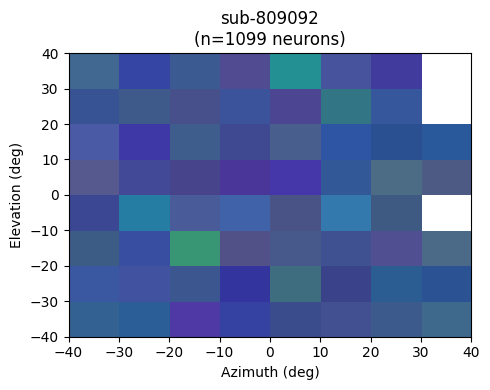

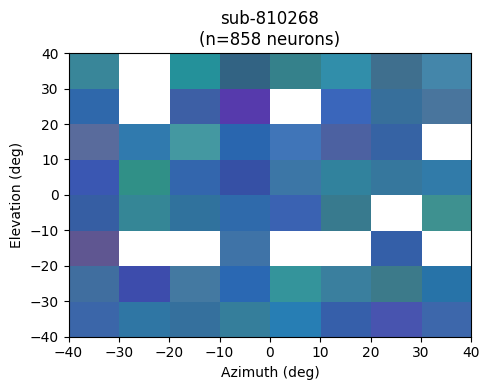

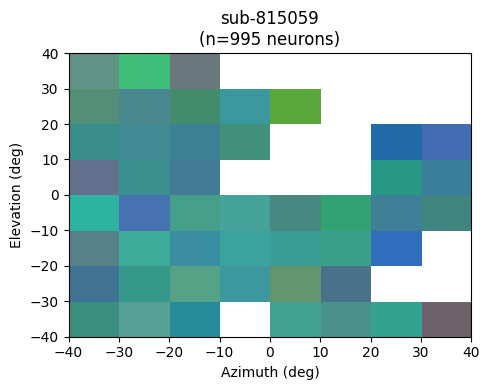

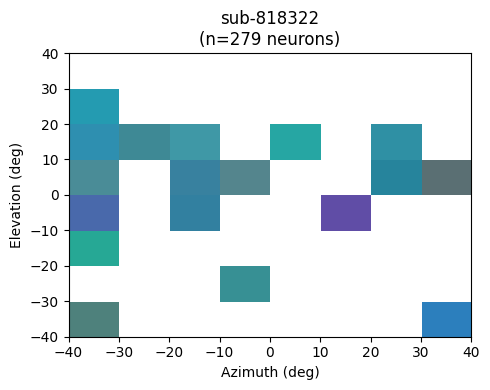

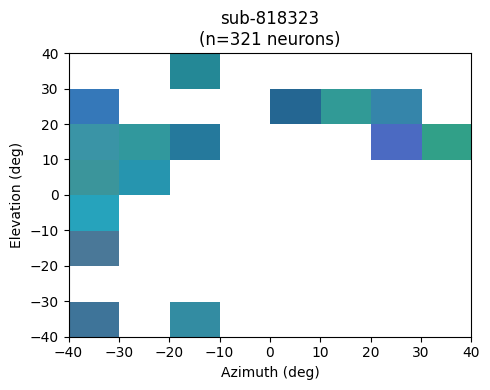

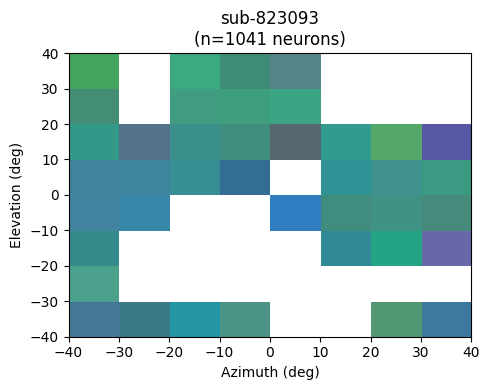

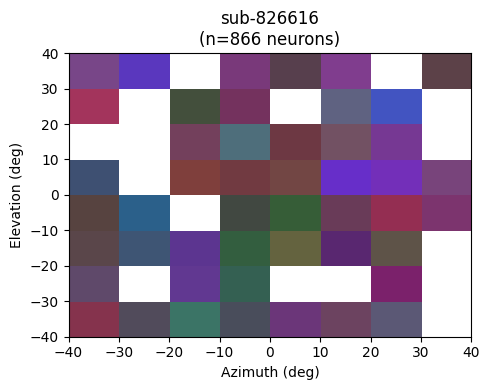

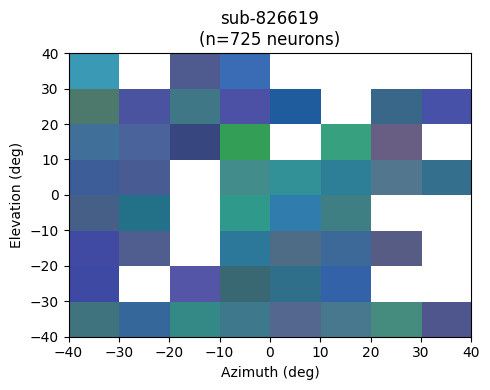

In [51]:
for mouse in df_v['mouse'].unique():
    mask_mouse = df_v['mouse'].values == mouse
    rf_x_m     = rf_x[mask_mouse]
    rf_y_m     = rf_y[mask_mouse]
    colors_m   = colors_v[mask_mouse]

    if len(rf_x_m) < 50:
        print(f"Skipping {mouse} — too few neurons ({len(rf_x_m)})")
        continue

    color_map_m = np.full((N_BINS, N_BINS, 3), np.nan)
    count_map_m = np.zeros((N_BINS, N_BINS))

    for i in range(N_BINS):
        for j in range(N_BINS):
            mask = (
                (rf_x_m >= x_bins[i]) & (rf_x_m < x_bins[i+1]) &
                (rf_y_m >= y_bins[j]) & (rf_y_m < y_bins[j+1])
            )
            if mask.sum() > 0:
                color_map_m[j, i] = colors_m[mask].mean(axis=0)
                count_map_m[j, i] = mask.sum()

    color_map_m[count_map_m < 5] = np.nan
    display_map_m = np.where(np.isnan(color_map_m), 1.0, color_map_m)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(display_map_m, origin='lower',
              extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
              aspect='auto')
    ax.set_title(f"{mouse}\n(n={mask_mouse.sum()} neurons)")
    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Elevation (deg)")
    plt.tight_layout()
    plt.savefig(data_dir / f"visual_field_map_{mouse}.png", dpi=150)
    plt.show()

## Do this in 3D space

PCs needed for 90% variance: 77
Optimal n_components: 29


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


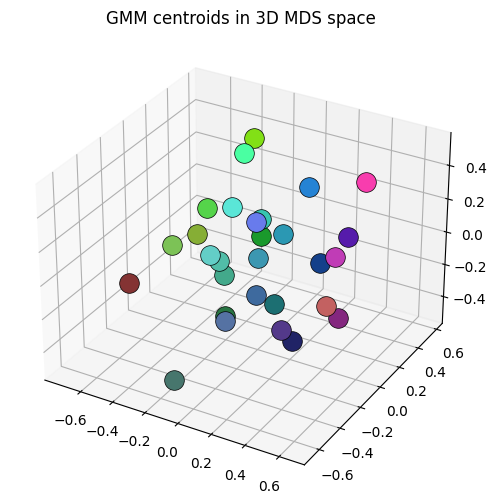

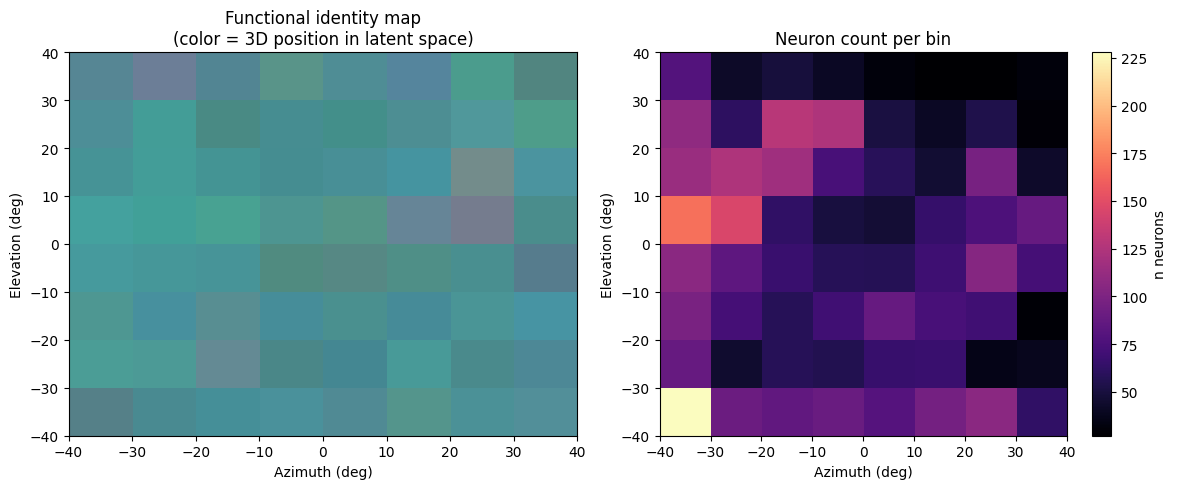

Done


In [86]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

# ── Load ──────────────────────────────────────────────────────────────────────
df              = pd.read_csv(data_dir / "unit_info_with_rf.csv")
response_matrix = np.load(data_dir / "none" / "response_matrix.npy")

# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_matrix, norm='l2')

pca   = PCA()
X_pca = pca.fit_transform(response_norm)

explained = np.cumsum(pca.explained_variance_ratio_)
n_pcs     = np.searchsorted(explained, 0.90) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

X_pca = X_pca[:, :n_pcs]

# ── Fit GMM ───────────────────────────────────────────────────────────────────
n_range = range(2, 30)
bics    = []
for n in n_range:
    gmm_n = GaussianMixture(n_components=n, covariance_type='diag', random_state=0).fit(X_pca)
    bics.append(gmm_n.bic(X_pca))

optimal_n = list(n_range)[np.argmin(bics)]
print(f"Optimal n_components: {optimal_n}")

gmm    = GaussianMixture(n_components=optimal_n, covariance_type='full', random_state=0)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)
probs  = gmm.predict_proba(X_pca)   # (n_units, n_clusters)

# ── Embed cluster centroids in 3D via MDS ─────────────────────────────────────
centroids    = gmm.means_                                          # (n_clusters, n_pcs)
mds          = MDS(n_components=3, dissimilarity='euclidean', random_state=0)
centroids_3d = mds.fit_transform(centroids)                        # (n_clusters, 3)

# Normalize each dim to [0, 1]
def norm01(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)

cx = norm01(centroids_3d[:, 0])
cy = norm01(centroids_3d[:, 1])
cz = norm01(centroids_3d[:, 2])

# ── Map 3D centroid positions to HSV colors ────────────────────────────────────
# Hue       = MDS dim 1  (full [0,1] range for max color variety)
# Saturation = MDS dim 2  (constrained to [0.4, 0.9] to avoid washed-out/oversaturated)
# Value      = MDS dim 3  (constrained to [0.4, 1.0] to stay visible)
cluster_colors = np.array([
    mcolors.hsv_to_rgb([cx[k], 0.4 + 0.5 * cy[k], 0.4 + 0.6 * cz[k]])
    for k in range(optimal_n)
])                                                                 # (n_clusters, 3)

# ── Project all neurons into MDS 3D space via soft GMM posteriors ──────────────
neuron_3d = probs @ centroids_3d        # (n_units, 3)

nx = norm01(neuron_3d[:, 0])
ny = norm01(neuron_3d[:, 1])
nz = norm01(neuron_3d[:, 2])
nx = np.clip(nx, 0, 1)
ny = np.clip(ny, 0, 1)
nz = np.clip(nz, 0, 1)

neuron_colors = np.array([
    mcolors.hsv_to_rgb([nx[i], 0.4 + 0.5 * ny[i], 0.4 + 0.6 * nz[i]])
    for i in range(len(nx))
])                                      # (n_units, 3)

# ── Plot 1: GMM centroids in 3D MDS space ─────────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')

for k in range(optimal_n):
    ax.scatter(*centroids_3d[k], color=cluster_colors[k],
               s=200, zorder=5, edgecolors='k', linewidths=0.5)

ax.set_title("GMM centroids in 3D MDS space")
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)
plt.savefig(data_dir / "gmm_centroids_mds_3d.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Visual field functional map ───────────────────────────────────────
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
df_v     = df[valid].reset_index(drop=True)
colors_v = neuron_colors[valid.values]

rf_x = df_v['rf_center_x'].values
rf_y = df_v['rf_center_y'].values

N_BINS  = 8
min_neurons = 10

x_bins  = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins  = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

color_map = np.full((N_BINS, N_BINS, 3), np.nan)
count_map = np.zeros((N_BINS, N_BINS))

for i in range(N_BINS):
    for j in range(N_BINS):
        mask = (
            (rf_x >= x_bins[i]) & (rf_x < x_bins[i + 1]) &
            (rf_y >= y_bins[j]) & (rf_y < y_bins[j + 1])
        )
        if mask.sum() > 0:
            color_map[j, i] = colors_v[mask].mean(axis=0)
            count_map[j, i] = mask.sum()


color_map[count_map < min_neurons] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: functional identity map
ax = axes[0]
display_map = np.where(np.isnan(color_map), 1.0, color_map)
ax.imshow(display_map, origin='lower',
          extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
          aspect='auto')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Functional identity map\n(color = 3D position in latent space)")

# Right: neuron count per bin
ax = axes[1]
im = ax.imshow(count_map, origin='lower',
               extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
               aspect='auto', cmap='magma')
plt.colorbar(im, ax=ax, label='n neurons')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Neuron count per bin")

plt.tight_layout()
plt.savefig(data_dir / "visual_field_functional_map_3d.png", dpi=150)
plt.show()

print("Done")

## Color by latent space -- maximally different colors

In [45]:
import matplotlib.cm as cm

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


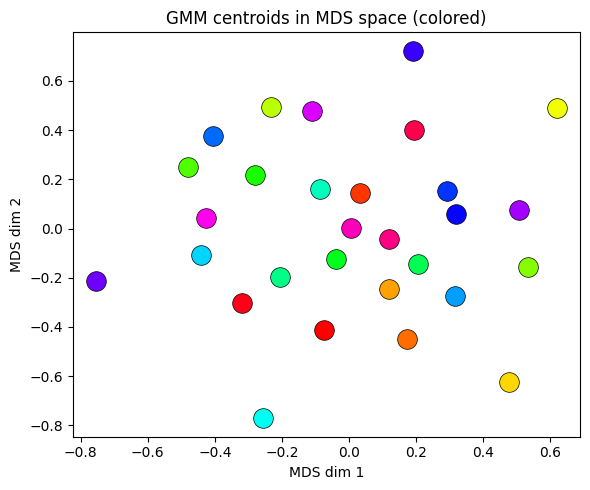

Neurons in restricted visual field: 1839


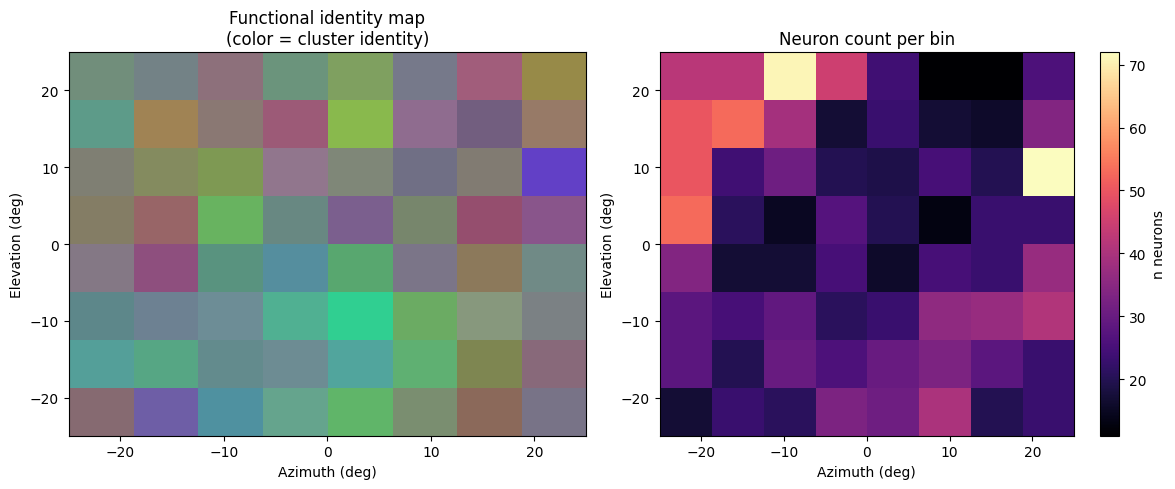

Done


In [46]:
# ── Embed cluster centroids in 2D via MDS (for sanity check plot only) ────────
centroids    = gmm.means_
mds          = MDS(n_components=2, dissimilarity='euclidean', random_state=0)
centroids_2d = mds.fit_transform(centroids)

# ── Assign maximally distinct colors per cluster ──────────────────────────────
cmap           = cm.get_cmap('hsv', optimal_n)
cluster_colors = np.array([cmap(k)[:3] for k in range(optimal_n)])  # (n_clusters, 3)
neuron_colors  = cluster_colors[labels]                               # (n_units, 3)

# ── Sanity check: MDS centroid plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(optimal_n):
    ax.scatter(centroids_2d[k, 0], centroids_2d[k, 1],
               color=cluster_colors[k], s=200, zorder=5, edgecolors='k', linewidths=0.5)
    ax.annotate(str(k), centroids_2d[k], fontsize=7, ha='center', va='center')
ax.set_title("GMM centroids in MDS space (colored)")
ax.set_xlabel("MDS dim 1")
ax.set_ylabel("MDS dim 2")
plt.tight_layout()
plt.savefig(data_dir / "gmm_centroids_mds.png", dpi=150)
plt.show()

# ── Build visual field map ─────────────────────────────────────────────────────
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
rf_x_all = df['rf_center_x'].values
rf_y_all = df['rf_center_y'].values

rf_x_mask = (rf_x_all >= -25) & (rf_x_all <= 25)
rf_y_mask = (rf_y_all >= -25) & (rf_y_all <= 25)
valid_rf  = valid.values & rf_x_mask & rf_y_mask

df_v     = df[valid_rf].reset_index(drop=True)
colors_v = neuron_colors[valid_rf]
rf_x     = df_v['rf_center_x'].values
rf_y     = df_v['rf_center_y'].values

print(f"Neurons in restricted visual field: {len(df_v)}")

# ── Bin the visual field ───────────────────────────────────────────────────────
N_BINS    = 8
min_neurons = 10
x_bins    = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins    = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

color_map = np.full((N_BINS, N_BINS, 3), np.nan)
count_map = np.zeros((N_BINS, N_BINS))

for i in range(N_BINS):
    for j in range(N_BINS):
        mask = (
            (rf_x >= x_bins[i]) & (rf_x < x_bins[i+1]) &
            (rf_y >= y_bins[j]) & (rf_y < y_bins[j+1])
        )
        if mask.sum() > 0:
            color_map[j, i] = colors_v[mask].mean(axis=0)
            count_map[j, i] = mask.sum()

color_map[count_map < min_neurons] = np.nan

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
display_map = np.where(np.isnan(color_map), 1.0, color_map)
ax.imshow(display_map, origin='lower',
          extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
          aspect='auto')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Functional identity map\n(color = cluster identity)")

ax = axes[1]
im = ax.imshow(count_map, origin='lower',
               extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
               aspect='auto', cmap='magma')
plt.colorbar(im, ax=ax, label='n neurons')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Neuron count per bin")

plt.tight_layout()
plt.savefig(data_dir / "visual_field_functional_map.png", dpi=150)
plt.show()

print("Done")

### Plot one mouse at a time

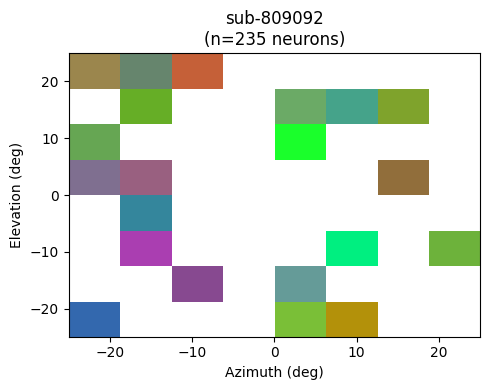

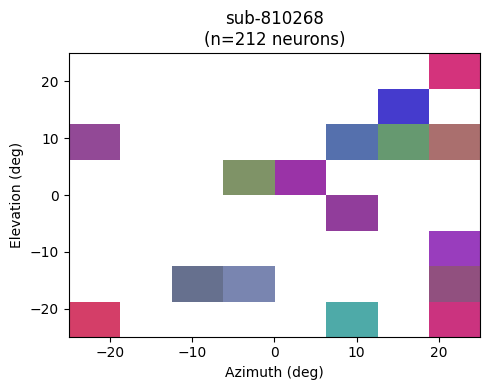

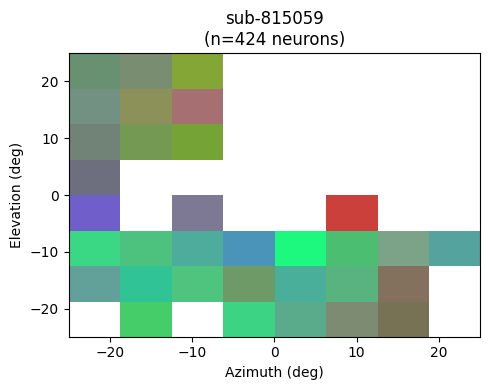

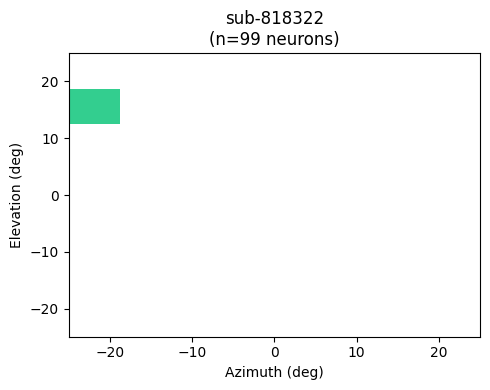

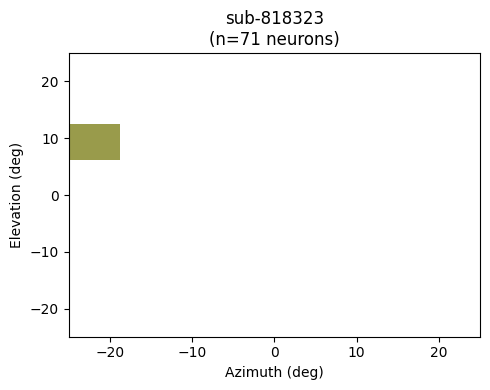

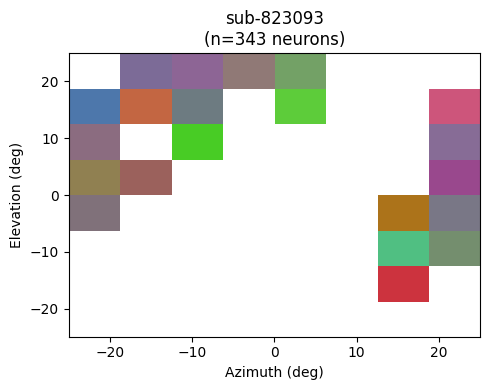

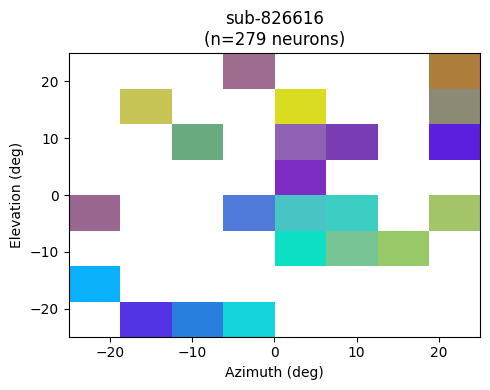

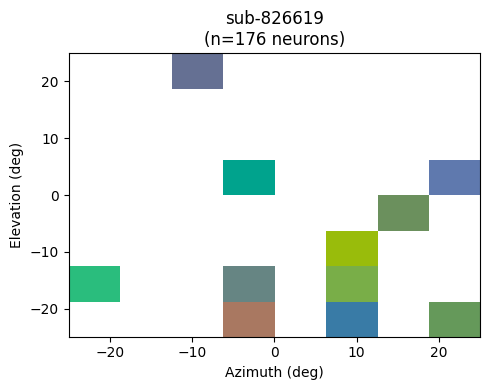

In [48]:
for mouse in df_v['mouse'].unique():
    mask_mouse = df_v['mouse'].values == mouse
    rf_x_m     = rf_x[mask_mouse]
    rf_y_m     = rf_y[mask_mouse]
    colors_m   = colors_v[mask_mouse]

    if len(rf_x_m) < 50:
        print(f"Skipping {mouse} — too few neurons ({len(rf_x_m)})")
        continue

    color_map_m = np.full((N_BINS, N_BINS, 3), np.nan)
    count_map_m = np.zeros((N_BINS, N_BINS))

    for i in range(N_BINS):
        for j in range(N_BINS):
            mask = (
                (rf_x_m >= x_bins[i]) & (rf_x_m < x_bins[i+1]) &
                (rf_y_m >= y_bins[j]) & (rf_y_m < y_bins[j+1])
            )
            if mask.sum() > 0:
                color_map_m[j, i] = colors_m[mask].mean(axis=0)
                count_map_m[j, i] = mask.sum()

    color_map_m[count_map_m < 5] = np.nan
    display_map_m = np.where(np.isnan(color_map_m), 1.0, color_map_m)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(display_map_m, origin='lower',
              extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
              aspect='auto')
    ax.set_title(f"{mouse}\n(n={mask_mouse.sum()} neurons)")
    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Elevation (deg)")
    plt.tight_layout()
    plt.savefig(data_dir / f"visual_field_map_{mouse}.png", dpi=150)
    plt.show()

## Check cluster composition by mouse

In [87]:
print(df_v.groupby('mouse')['rf_center_x'].describe())

             count      mean        std   min        25%       50%        75%  \
mouse                                                                           
sub-809092  1099.0 -0.502447  27.490584 -40.0 -23.254165 -0.661672  25.517887   
sub-810268   858.0  0.923889  27.063821 -40.0 -22.340010  0.171157  24.504378   
sub-815059   995.0 -2.809844  25.111126 -40.0 -23.654836 -7.783756  17.017395   
sub-818322   279.0 -0.494630  27.792770 -40.0 -24.419064 -4.838101  26.231791   
sub-818323   321.0  0.036840  30.433909 -40.0 -31.402874 -0.433277  31.342861   
sub-823093  1041.0 -1.398426  27.180069 -40.0 -25.988357 -6.736296  25.697379   
sub-826616   866.0  2.781745  27.421902 -40.0 -21.385780  3.985531  25.375924   
sub-826619   725.0  2.845058  28.243771 -40.0 -21.704799  3.425307  29.888555   

             max  
mouse             
sub-809092  40.0  
sub-810268  40.0  
sub-815059  40.0  
sub-818322  40.0  
sub-818323  40.0  
sub-823093  40.0  
sub-826616  40.0  
sub-826619  40.0  

gmm_label     0     1     2     3     4     5     6     7     8     9   ...  \
mouse                                                                   ...   
sub-809092  0.03  0.01  0.17  0.04  0.00  0.00  0.01  0.03  0.01  0.01  ...   
sub-810268  0.02  0.02  0.01  0.03  0.00  0.00  0.01  0.01  0.01  0.01  ...   
sub-815059  0.04  0.13  0.00  0.03  0.00  0.00  0.04  0.03  0.05  0.03  ...   
sub-818322  0.02  0.18  0.00  0.03  0.00  0.00  0.02  0.01  0.01  0.04  ...   
sub-818323  0.02  0.28  0.00  0.06  0.00  0.00  0.01  0.00  0.01  0.02  ...   
sub-823093  0.03  0.13  0.00  0.02  0.00  0.00  0.05  0.01  0.03  0.03  ...   
sub-826616  0.01  0.00  0.01  0.01  0.16  0.14  0.00  0.01  0.00  0.01  ...   
sub-826619  0.02  0.01  0.08  0.05  0.00  0.00  0.02  0.02  0.01  0.02  ...   

gmm_label     19    20    21    22    23    24    25    26    27    28  
mouse                                                                   
sub-809092  0.02  0.00  0.00  0.02  0.01  0.00  0.07  0.05  0.0

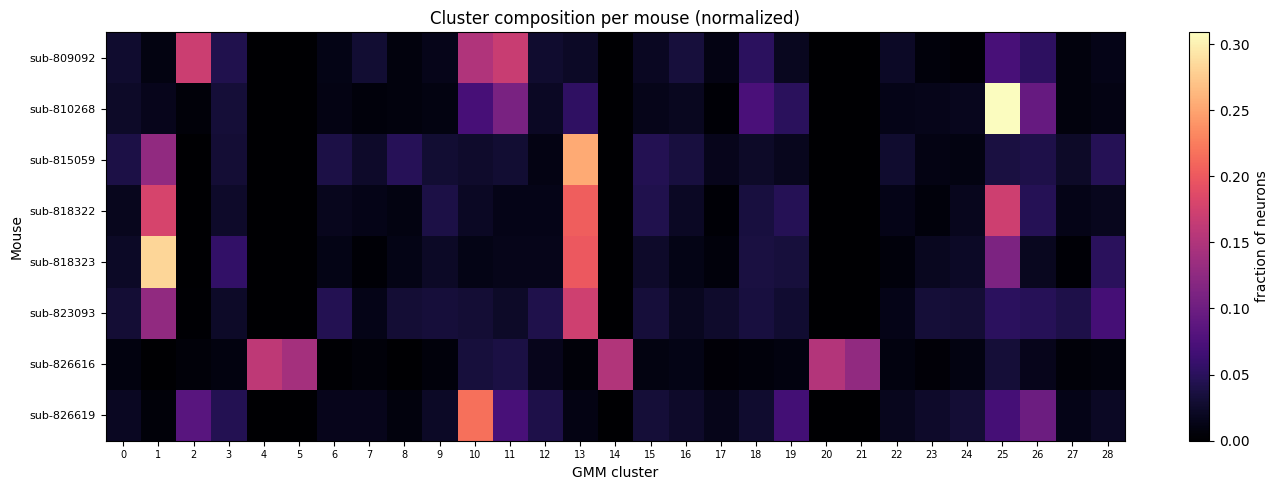

In [88]:
# What is the cluster composition per mouse?
cluster_counts = pd.crosstab(df['mouse'], df['gmm_label'], normalize='index')
print(cluster_counts.round(2))

# Plot as a heatmap
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(cluster_counts.values, aspect='auto', cmap='magma')
ax.set_xticks(range(optimal_n))
ax.set_xticklabels(range(optimal_n), fontsize=7)
ax.set_yticks(range(len(cluster_counts)))
ax.set_yticklabels(cluster_counts.index, fontsize=8)
ax.set_xlabel("GMM cluster")
ax.set_ylabel("Mouse")
ax.set_title("Cluster composition per mouse (normalized)")
plt.colorbar(im, ax=ax, label='fraction of neurons')
plt.tight_layout()
plt.savefig(data_dir / "cluster_composition_per_mouse.png", dpi=150)
plt.show()

## Normalize within mouse

In [89]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import colorsys

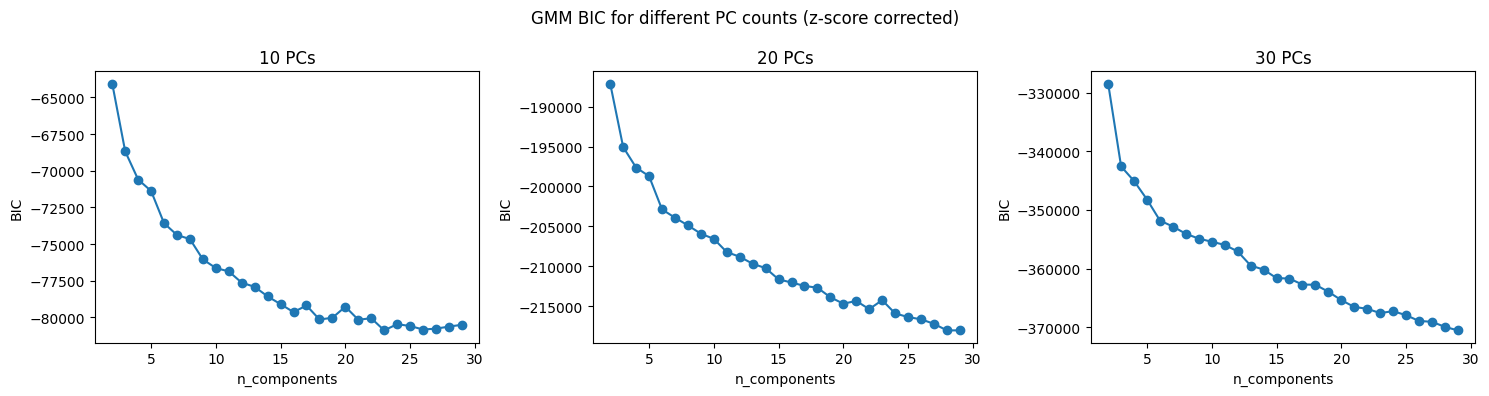

In [90]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")

# ── Load ──────────────────────────────────────────────────────────────────────
df              = pd.read_csv(data_dir / "unit_info_with_rf.csv")
response_matrix = np.load(data_dir / "none" / "response_matrix.npy")

# ── Z-score within each mouse to remove between-mouse variability ─────────────
mouse_labels = df['mouse'].values
response_corrected = response_matrix.copy()

for mouse in np.unique(mouse_labels):
    mask = mouse_labels == mouse
    mu   = response_corrected[mask].mean(axis=0)
    sd   = response_corrected[mask].std(axis=0) + 1e-8
    response_corrected[mask] = (response_corrected[mask] - mu) / sd

# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_corrected, norm='l2')

pca   = PCA()
X_pca_full = pca.fit_transform(response_norm)

# Plot BIC for a few PC choices so we can pick the best
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n_range = range(2, 30)

for ax, n_pcs in zip(axes, [10, 20, 30]):
    X_pca = X_pca_full[:, :n_pcs]
    bics  = []
    for n in n_range:
        gmm_n = GaussianMixture(n_components=n, covariance_type='diag', random_state=0).fit(X_pca)
        bics.append(gmm_n.bic(X_pca))
    ax.plot(list(n_range), bics, marker='o')
    ax.set_title(f"{n_pcs} PCs")
    ax.set_xlabel("n_components")
    ax.set_ylabel("BIC")

plt.suptitle("GMM BIC for different PC counts (z-score corrected)")
plt.tight_layout()
plt.savefig(data_dir / "gmm_bic_corrected.png", dpi=150)
plt.show()

Using 10 PCs, 15 clusters
Cluster sizes:
  Cluster 11: 1029 neurons (16.6%)
  Cluster  4:  644 neurons (10.4%)
  Cluster  1:  612 neurons (9.9%)
  Cluster  7:  550 neurons (8.9%)
  Cluster  3:  498 neurons (8.1%)
  Cluster 13:  444 neurons (7.2%)
  Cluster  9:  443 neurons (7.2%)
  Cluster 12:  389 neurons (6.3%)
  Cluster 14:  337 neurons (5.4%)
  Cluster 10:  289 neurons (4.7%)
  Cluster  8:  259 neurons (4.2%)
  Cluster  0:  220 neurons (3.6%)
  Cluster  6:  172 neurons (2.8%)
  Cluster  2:  170 neurons (2.7%)
  Cluster  5:  128 neurons (2.1%)


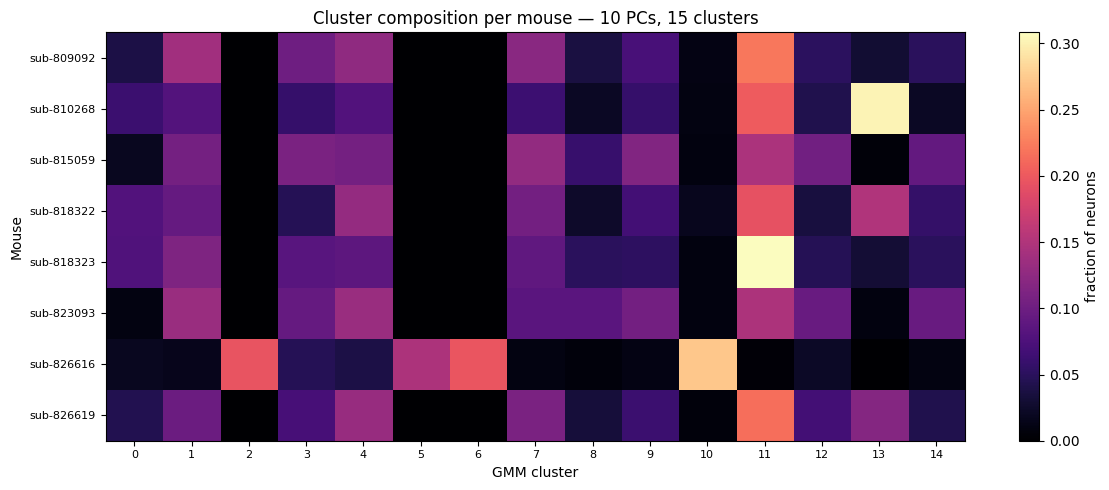

c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


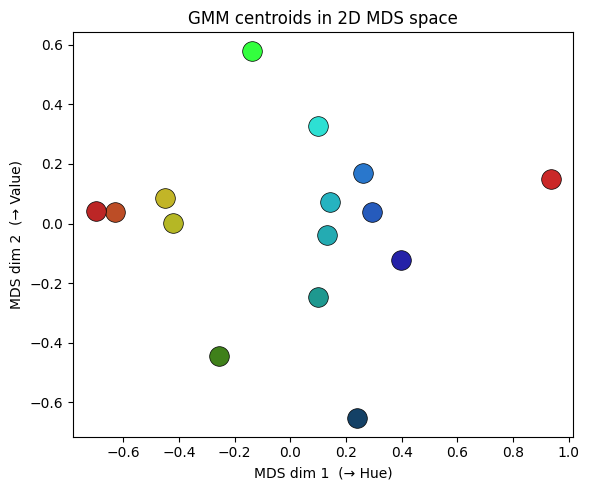

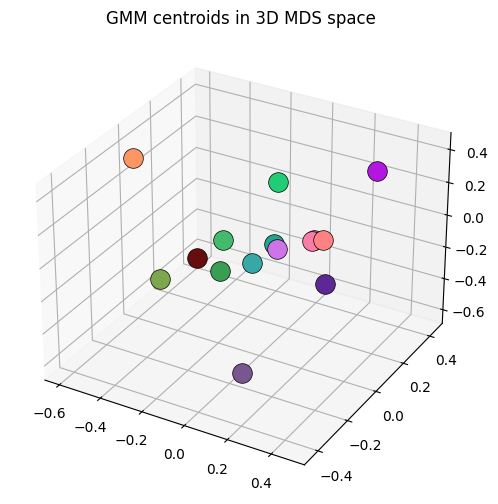

Neurons in restricted visual field: 1839


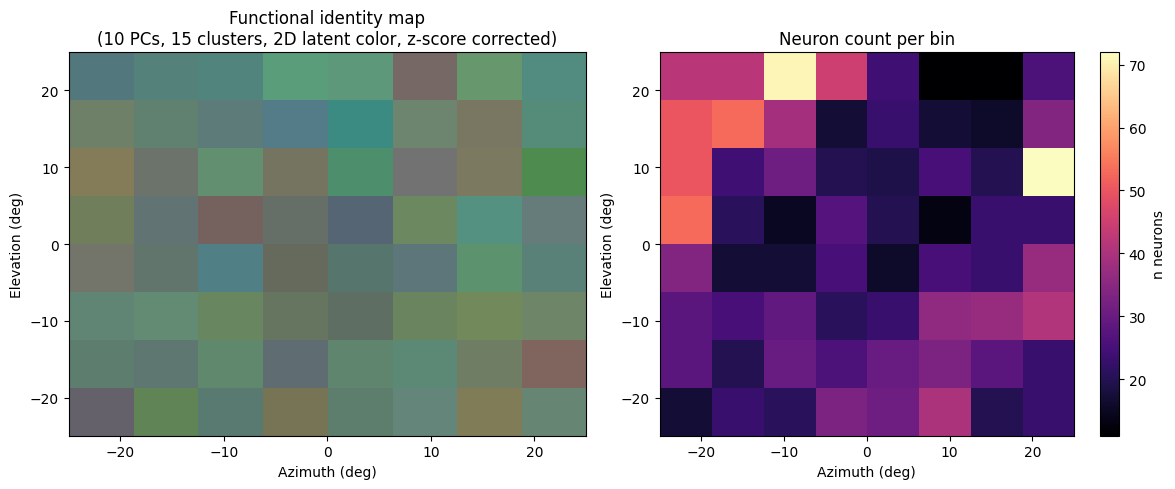

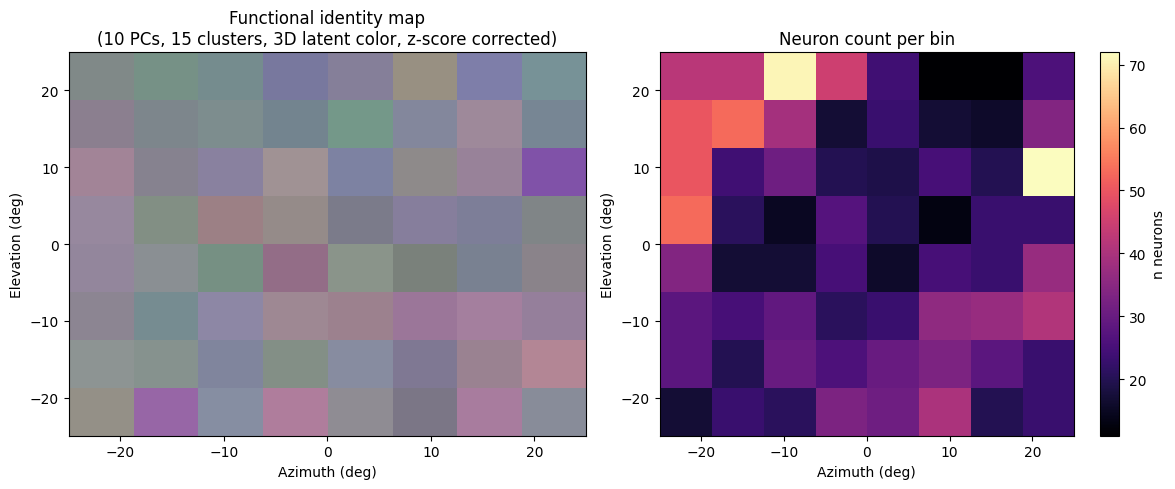

Done


In [93]:
# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_corrected, norm='l2')

pca        = PCA()
X_pca_full = pca.fit_transform(response_norm)

N_PCS      = 10   # fixed — BIC has no clear elbow
N_CLUSTERS = 15   # biologically motivated, adjust if needed
X_pca = X_pca_full[:, :N_PCS]

print(f"Using {N_PCS} PCs, {N_CLUSTERS} clusters")

# ── Fit GMM ───────────────────────────────────────────────────────────────────
gmm   = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full', random_state=0)
gmm.fit(X_pca)
labels = gmm.predict(X_pca)
probs  = gmm.predict_proba(X_pca)

print("Cluster sizes:")
unique, counts = np.unique(labels, return_counts=True)
for k, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"  Cluster {k:2d}: {c:4d} neurons ({100*c/len(labels):.1f}%)")

# ── Check cluster composition per mouse ───────────────────────────────────────
df['gmm_label_corrected'] = labels
cluster_counts = pd.crosstab(df['mouse'], df['gmm_label_corrected'], normalize='index')

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(cluster_counts.values, aspect='auto', cmap='magma')
ax.set_xticks(range(N_CLUSTERS))
ax.set_xticklabels(range(N_CLUSTERS), fontsize=8)
ax.set_yticks(range(len(cluster_counts)))
ax.set_yticklabels(cluster_counts.index, fontsize=8)
ax.set_xlabel("GMM cluster")
ax.set_ylabel("Mouse")
ax.set_title(f"Cluster composition per mouse — {N_PCS} PCs, {N_CLUSTERS} clusters")
plt.colorbar(im, ax=ax, label='fraction of neurons')
plt.tight_layout()
plt.savefig(data_dir / "cluster_composition_corrected.png", dpi=150)
plt.show()

# ── Shared helper ─────────────────────────────────────────────────────────────
def norm01(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-8)

centroids = gmm.means_

# ── 2D MDS + colors (original) ────────────────────────────────────────────────
mds_2d       = MDS(n_components=2, dissimilarity='euclidean', random_state=0)
centroids_2d = mds_2d.fit_transform(centroids)

cx2 = norm01(centroids_2d[:, 0])
cy2 = norm01(centroids_2d[:, 1])

cluster_colors_2d = np.array([
    mcolors.hsv_to_rgb([cx2[k], 0.8, 0.4 + 0.6 * cy2[k]])
    for k in range(N_CLUSTERS)
])

neuron_2d = probs @ centroids_2d
nx2 = np.clip(norm01(neuron_2d[:, 0]), 0, 1)
ny2 = np.clip(norm01(neuron_2d[:, 1]), 0, 1)

neuron_colors_2d = np.array([
    mcolors.hsv_to_rgb([nx2[i], 0.8, 0.4 + 0.6 * ny2[i]])
    for i in range(len(nx2))
])

# ── 3D MDS + colors ───────────────────────────────────────────────────────────
mds_3d       = MDS(n_components=3, dissimilarity='euclidean', random_state=0)
centroids_3d = mds_3d.fit_transform(centroids)

cx3 = norm01(centroids_3d[:, 0])
cy3 = norm01(centroids_3d[:, 1])
cz3 = norm01(centroids_3d[:, 2])

cluster_colors_3d = np.array([
    mcolors.hsv_to_rgb([cx3[k], 0.4 + 0.5 * cy3[k], 0.4 + 0.6 * cz3[k]])
    for k in range(N_CLUSTERS)
])

neuron_3d = probs @ centroids_3d
nx3 = np.clip(norm01(neuron_3d[:, 0]), 0, 1)
ny3 = np.clip(norm01(neuron_3d[:, 1]), 0, 1)
nz3 = np.clip(norm01(neuron_3d[:, 2]), 0, 1)

neuron_colors_3d = np.array([
    mcolors.hsv_to_rgb([nx3[i], 0.4 + 0.5 * ny3[i], 0.4 + 0.6 * nz3[i]])
    for i in range(len(nx3))
])

# ── MDS sanity check: 2D ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
for k in range(N_CLUSTERS):
    ax.scatter(centroids_2d[k, 0], centroids_2d[k, 1],
               color=cluster_colors_2d[k], s=200, zorder=5, edgecolors='k', linewidths=0.5)
    ax.annotate(str(k), centroids_2d[k], fontsize=8, ha='center', va='center')
ax.set_title("GMM centroids in 2D MDS space")
ax.set_xlabel("MDS dim 1  (→ Hue)")
ax.set_ylabel("MDS dim 2  (→ Value)")
plt.tight_layout()
plt.savefig(data_dir / "gmm_centroids_mds_2d_corrected.png", dpi=150)
plt.show()

# ── MDS sanity check: 3D ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection='3d')
for k in range(N_CLUSTERS):
    ax.scatter(*centroids_3d[k], color=cluster_colors_3d[k],
               s=200, zorder=5, edgecolors='k', linewidths=0.5)
ax.set_title("GMM centroids in 3D MDS space")
ax.zaxis.set_rotate_label(False)
ax.zaxis.label.set_rotation(90)
plt.savefig(data_dir / "gmm_centroids_mds_3d_corrected.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Visual field filtering (shared) ───────────────────────────────────────────
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
rf_x_all = df['rf_center_x'].values
rf_y_all = df['rf_center_y'].values

rf_x_mask = (rf_x_all >= -25) & (rf_x_all <= 25)
rf_y_mask = (rf_y_all >= -25) & (rf_y_all <= 25)
valid_rf  = valid.values & rf_x_mask & rf_y_mask

df_v = df[valid_rf].reset_index(drop=True)
rf_x = df_v['rf_center_x'].values
rf_y = df_v['rf_center_y'].values

print(f"Neurons in restricted visual field: {len(df_v)}")

N_BINS      = 8
min_neurons = 10
x_bins = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

def build_maps(colors_v):
    color_map = np.full((N_BINS, N_BINS, 3), np.nan)
    count_map = np.zeros((N_BINS, N_BINS))
    for i in range(N_BINS):
        for j in range(N_BINS):
            mask = (
                (rf_x >= x_bins[i]) & (rf_x < x_bins[i+1]) &
                (rf_y >= y_bins[j]) & (rf_y < y_bins[j+1])
            )
            if mask.sum() > 0:
                color_map[j, i] = colors_v[mask].mean(axis=0)
                count_map[j, i] = mask.sum()
    color_map[count_map < min_neurons] = np.nan
    return color_map, count_map

def plot_visual_field(color_map, count_map, title_suffix, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    display_map = np.where(np.isnan(color_map), 1.0, color_map)
    ax.imshow(display_map, origin='lower',
              extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
              aspect='auto')
    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Elevation (deg)")
    ax.set_title(f"Functional identity map\n({title_suffix})")

    ax = axes[1]
    im = ax.imshow(count_map, origin='lower',
                   extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
                   aspect='auto', cmap='magma')
    plt.colorbar(im, ax=ax, label='n neurons')
    ax.set_xlabel("Azimuth (deg)")
    ax.set_ylabel("Elevation (deg)")
    ax.set_title("Neuron count per bin")

    plt.tight_layout()
    plt.savefig(data_dir / save_name, dpi=150)
    plt.show()

# ── Visual field map: 2D coloring ─────────────────────────────────────────────
colors_v_2d        = neuron_colors_2d[valid_rf]
color_map_2d, count_map = build_maps(colors_v_2d)
plot_visual_field(color_map_2d, count_map,
                  f"{N_PCS} PCs, {N_CLUSTERS} clusters, 2D latent color, z-score corrected",
                  "visual_field_functional_map_2d_corrected.png")

# ── Visual field map: 3D coloring ─────────────────────────────────────────────
colors_v_3d           = neuron_colors_3d[valid_rf]
color_map_3d, count_map = build_maps(colors_v_3d)
plot_visual_field(color_map_3d, count_map,
                  f"{N_PCS} PCs, {N_CLUSTERS} clusters, 3D latent color, z-score corrected",
                  "visual_field_functional_map_3d_corrected.png")

print("Done")

Running UMAP...


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


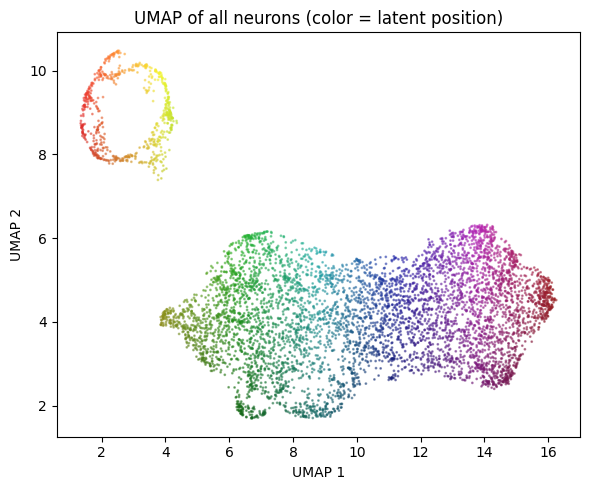

In [58]:
from umap import UMAP

# ── Project all neurons to 2D continuously via UMAP ──────────────────────────
print("Running UMAP...")
umap  = UMAP(n_components=2, random_state=0, n_neighbors=30, min_dist=0.1)
X_2d  = umap.fit_transform(X_pca)      # (n_units, 2) — every neuron gets its own 2D position

# Normalize to [0, 1]
nx = (X_2d[:, 0] - X_2d[:, 0].min()) / (X_2d[:, 0].ptp() + 1e-8)
ny = (X_2d[:, 1] - X_2d[:, 1].min()) / (X_2d[:, 1].ptp() + 1e-8)

# Smooth HSV color per neuron from continuous 2D position
neuron_colors = np.array([
    mcolors.hsv_to_rgb([nx[i], 0.8, 0.4 + 0.6 * ny[i]])
    for i in range(len(nx))
])

# Sanity check — plot UMAP colored by these colors
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=neuron_colors, s=1, alpha=0.5)
ax.set_title("UMAP of all neurons (color = latent position)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(data_dir / "umap_colored.png", dpi=150)
plt.show()

Using 10 PCs
Running UMAP...


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done


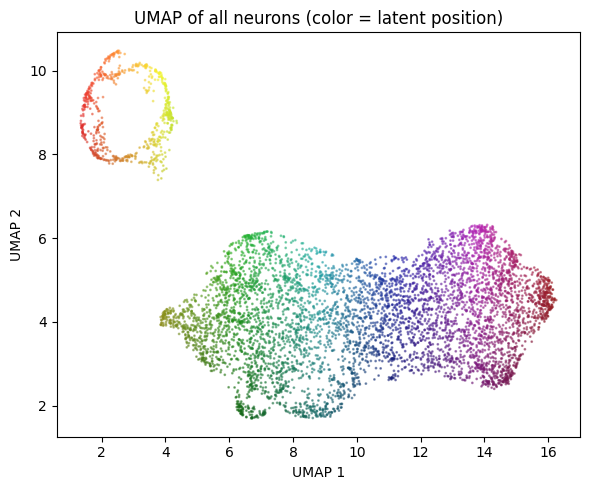

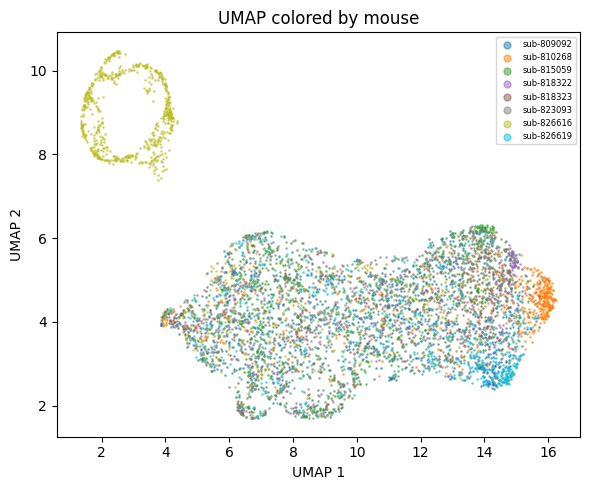

Neurons in restricted visual field: 1839


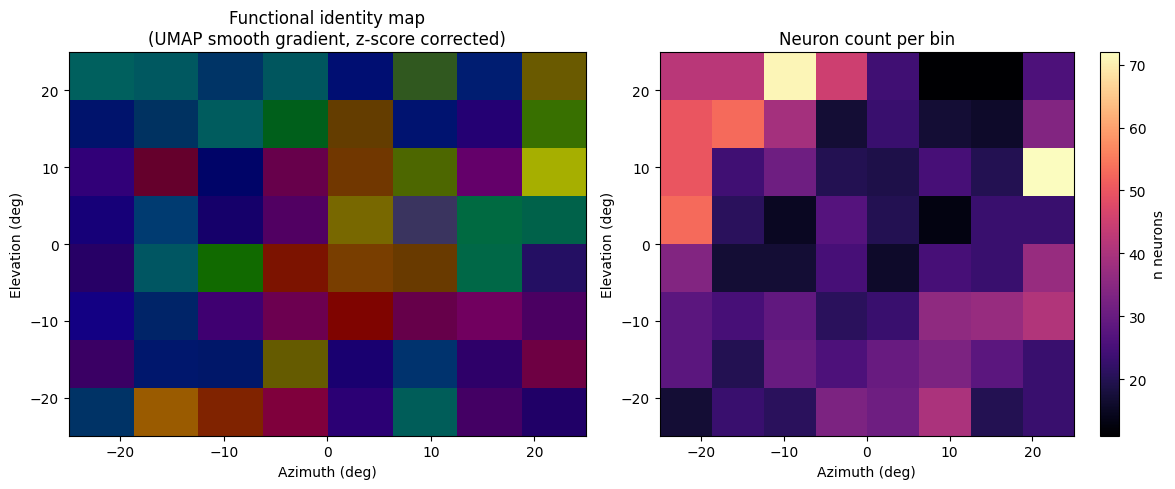

Done


In [75]:
# ── Z-score within each mouse ─────────────────────────────────────────────────
mouse_labels = df['mouse'].values
response_corrected = response_matrix.copy()

for mouse in np.unique(mouse_labels):
    mask = mouse_labels == mouse
    mu   = response_corrected[mask].mean(axis=0)
    sd   = response_corrected[mask].std(axis=0) + 1e-8
    response_corrected[mask] = (response_corrected[mask] - mu) / sd

# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_corrected, norm='l2')

pca   = PCA()
X_pca_full = pca.fit_transform(response_norm)

N_PCS = 10
X_pca = X_pca_full[:, :N_PCS]
print(f"Using {N_PCS} PCs")

# ── UMAP: project every neuron to 2D continuously ────────────────────────────
print("Running UMAP...")
umap_model = UMAP(n_components=2, random_state=0, n_neighbors=30, min_dist=0.1)
X_2d       = umap_model.fit_transform(X_pca)    # (n_units, 2)
print("UMAP done")

# ── Assign smooth HSV color from continuous 2D UMAP position ─────────────────
nx = (X_2d[:, 0] - X_2d[:, 0].min()) / (X_2d[:, 0].ptp() + 1e-8)
ny = (X_2d[:, 1] - X_2d[:, 1].min()) / (X_2d[:, 1].ptp() + 1e-8)

neuron_colors = np.array([
    mcolors.hsv_to_rgb([nx[i], 0.8, 0.4 + 0.6 * ny[i]])
    for i in range(len(nx))
])                                               # (n_units, 3)

# ── UMAP sanity check ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=neuron_colors, s=1, alpha=0.5)
ax.set_title("UMAP of all neurons (color = latent position)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(data_dir / "umap_colored.png", dpi=150)
plt.show()

# ── Also color UMAP by mouse as sanity check ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
mice   = df['mouse'].values
unique_mice = np.unique(mice)
cmap_m = plt.cm.get_cmap('tab10', len(unique_mice))
for i, mouse in enumerate(unique_mice):
    mask = mice == mouse
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=1, alpha=0.5,
               color=cmap_m(i), label=mouse)
ax.legend(fontsize=6, markerscale=5)
ax.set_title("UMAP colored by mouse")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig(data_dir / "umap_by_mouse.png", dpi=150)
plt.show()

# ── Visual field map ──────────────────────────────────────────────────────────
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
rf_x_all = df['rf_center_x'].values
rf_y_all = df['rf_center_y'].values

rf_x_mask = (rf_x_all >= -25) & (rf_x_all <= 25)
rf_y_mask = (rf_y_all >= -25) & (rf_y_all <= 25)
valid_rf  = valid.values & rf_x_mask & rf_y_mask

df_v     = df[valid_rf].reset_index(drop=True)
colors_v = neuron_colors[valid_rf]
rf_x     = df_v['rf_center_x'].values
rf_y     = df_v['rf_center_y'].values

print(f"Neurons in restricted visual field: {len(df_v)}")

N_BINS      = 8
min_neurons = 10
x_bins = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

color_map = np.full((N_BINS, N_BINS, 3), np.nan)
count_map = np.zeros((N_BINS, N_BINS))

for i in range(N_BINS):
    for j in range(N_BINS):
        mask = (
            (rf_x >= x_bins[i]) & (rf_x < x_bins[i+1]) &
            (rf_y >= y_bins[j]) & (rf_y < y_bins[j+1])
        )
        if mask.sum() > 0:
            color_map[j, i] = colors_v[mask].mean(axis=0)
            count_map[j, i] = mask.sum()

color_map[count_map < min_neurons] = np.nan

# ── Boost saturation ──────────────────────────────────────────────────────────
color_map_vivid = color_map.copy()
for i in range(N_BINS):
    for j in range(N_BINS):
        if not np.isnan(color_map[j, i, 0]):
            h, s, v = colorsys.rgb_to_hsv(*color_map[j, i])
            color_map_vivid[j, i] = mcolors.hsv_to_rgb([h, min(s * 10, 1.0), v])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
display_map = np.where(np.isnan(color_map_vivid), 1.0, color_map_vivid)
ax.imshow(display_map, origin='lower',
          extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
          aspect='auto')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title(f"Functional identity map\n(UMAP smooth gradient, z-score corrected)")

ax = axes[1]
im = ax.imshow(count_map, origin='lower',
               extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
               aspect='auto', cmap='magma')
plt.colorbar(im, ax=ax, label='n neurons')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Neuron count per bin")

plt.tight_layout()
plt.savefig(data_dir / "visual_field_functional_map_umap.png", dpi=150)
plt.show()

print("Done")

### Remove weird mice and saturate color

In [64]:
import colorsys

Kept 3735 neurons from 5 mice
sub-809092    1099
sub-823093    1041
sub-815059     995
sub-818323     321
sub-818322     279
Name: mouse, dtype: int64
Using 10 PCs
Running UMAP...


c:\Users\MaryBeth\anaconda3\envs\openscope\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done


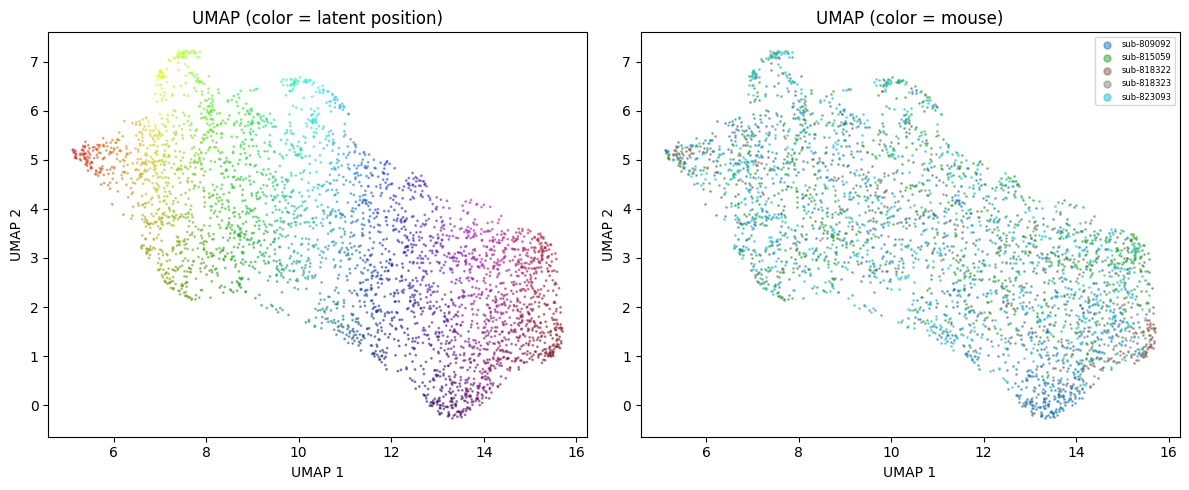

Neurons in restricted visual field: 1172


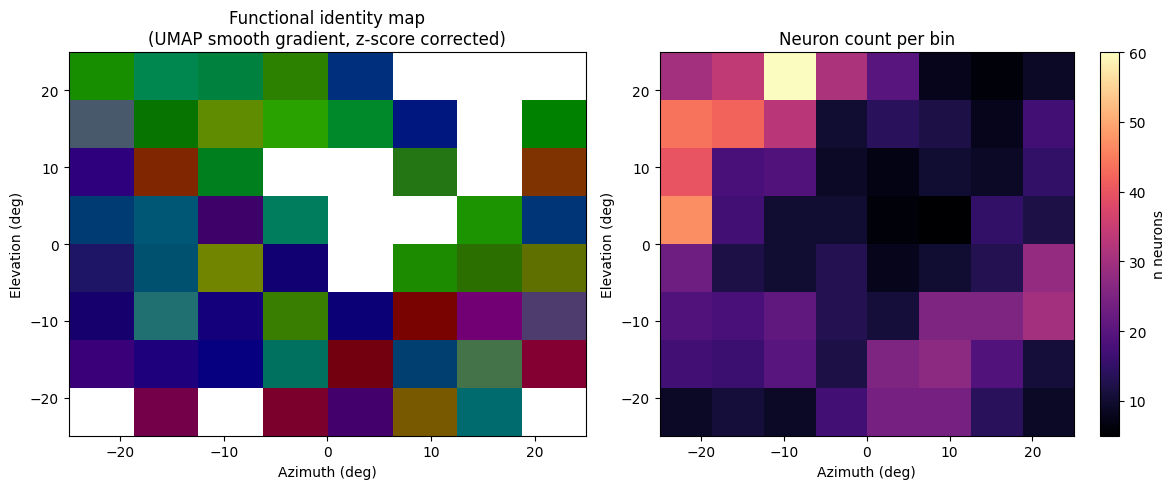

UMAP dim 2 vs elevation: r=0.075, p=1.046e-02
UMAP dim 2 vs azimuth:   r=0.091, p=1.924e-03
Done


In [77]:
# ── Filter mice ───────────────────────────────────────────────────────────────
EXCLUDE_MICE = ['sub-826616', 'sub-810268', 'sub-826619']

mask_mice       = ~df['mouse'].isin(EXCLUDE_MICE)
df              = df[mask_mice].reset_index(drop=True)
response_matrix = response_matrix[mask_mice.values]

print(f"Kept {len(df)} neurons from {df['mouse'].nunique()} mice")
print(df['mouse'].value_counts())

# ── Z-score within each mouse ─────────────────────────────────────────────────
mouse_labels = df['mouse'].values
response_corrected = response_matrix.copy()

for mouse in np.unique(mouse_labels):
    mask = mouse_labels == mouse
    mu   = response_corrected[mask].mean(axis=0)
    sd   = response_corrected[mask].std(axis=0) + 1e-8
    response_corrected[mask] = (response_corrected[mask] - mu) / sd

# ── Normalize + PCA ───────────────────────────────────────────────────────────
response_norm = normalize(response_corrected, norm='l2')

pca        = PCA()
X_pca_full = pca.fit_transform(response_norm)

N_PCS = 10
X_pca = X_pca_full[:, :N_PCS]
print(f"Using {N_PCS} PCs")

# ── UMAP ──────────────────────────────────────────────────────────────────────
print("Running UMAP...")
umap_model = UMAP(n_components=2, random_state=0, n_neighbors=30, min_dist=0.1)
X_2d       = umap_model.fit_transform(X_pca)
print("UMAP done")

# ── Smooth HSV color from continuous 2D UMAP position ────────────────────────
nx = (X_2d[:, 0] - X_2d[:, 0].min()) / (X_2d[:, 0].ptp() + 1e-8)
ny = (X_2d[:, 1] - X_2d[:, 1].min()) / (X_2d[:, 1].ptp() + 1e-8)

neuron_colors = np.array([
    mcolors.hsv_to_rgb([nx[i], 0.8, 0.4 + 0.6 * ny[i]])
    for i in range(len(nx))
])

# ── UMAP sanity check — colored by latent position ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(X_2d[:, 0], X_2d[:, 1], c=neuron_colors, s=1, alpha=0.5)
ax.set_title("UMAP (color = latent position)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

# ── UMAP sanity check — colored by mouse ─────────────────────────────────────
ax = axes[1]
unique_mice = np.unique(mouse_labels)
cmap_m      = plt.cm.get_cmap('tab10', len(unique_mice))
for i, mouse in enumerate(unique_mice):
    mask = mouse_labels == mouse
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=1, alpha=0.5,
               color=cmap_m(i), label=mouse)
ax.legend(fontsize=6, markerscale=5)
ax.set_title("UMAP (color = mouse)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.savefig(data_dir / "umap_sanity_checks.png", dpi=150)
plt.show()

# ── Visual field map ──────────────────────────────────────────────────────────
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
rf_x_all = df['rf_center_x'].values
rf_y_all = df['rf_center_y'].values

rf_x_mask = (rf_x_all >= -25) & (rf_x_all <= 25)
rf_y_mask = (rf_y_all >= -25) & (rf_y_all <= 25)
valid_rf  = valid.values & rf_x_mask & rf_y_mask

df_v     = df[valid_rf].reset_index(drop=True)
colors_v = neuron_colors[valid_rf]
rf_x     = df_v['rf_center_x'].values
rf_y     = df_v['rf_center_y'].values

print(f"Neurons in restricted visual field: {len(df_v)}")

N_BINS      = 8
min_neurons = 10
x_bins = np.linspace(rf_x.min(), rf_x.max(), N_BINS + 1)
y_bins = np.linspace(rf_y.min(), rf_y.max(), N_BINS + 1)

color_map = np.full((N_BINS, N_BINS, 3), np.nan)
count_map = np.zeros((N_BINS, N_BINS))

for i in range(N_BINS):
    for j in range(N_BINS):
        mask = (
            (rf_x >= x_bins[i]) & (rf_x < x_bins[i+1]) &
            (rf_y >= y_bins[j]) & (rf_y < y_bins[j+1])
        )
        if mask.sum() > 0:
            color_map[j, i] = colors_v[mask].mean(axis=0)
            count_map[j, i] = mask.sum()

color_map[count_map < min_neurons] = np.nan

# ── Boost saturation ──────────────────────────────────────────────────────────
color_map_vivid = color_map.copy()
for i in range(N_BINS):
    for j in range(N_BINS):
        if not np.isnan(color_map[j, i, 0]):
            h, s, v = colorsys.rgb_to_hsv(*color_map[j, i])
            color_map_vivid[j, i] = mcolors.hsv_to_rgb([h, min(s * 10, 1.0), v])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
display_map = np.where(np.isnan(color_map_vivid), 1.0, color_map_vivid)
ax.imshow(display_map, origin='lower',
          extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
          aspect='auto')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Functional identity map\n(UMAP smooth gradient, z-score corrected)")

ax = axes[1]
im = ax.imshow(count_map, origin='lower',
               extent=[rf_x.min(), rf_x.max(), rf_y.min(), rf_y.max()],
               aspect='auto', cmap='magma')
plt.colorbar(im, ax=ax, label='n neurons')
ax.set_xlabel("Azimuth (deg)")
ax.set_ylabel("Elevation (deg)")
ax.set_title("Neuron count per bin")

plt.tight_layout()
plt.savefig(data_dir / "visual_field_functional_map_umap.png", dpi=150)
plt.show()

# ny is already computed — it's the UMAP dim 2 position normalized to [0,1]
# rf_y is elevation for valid RF neurons
valid_rf_vals = valid_rf if 'valid_rf' in dir() else (df['rf_center_x'].notna() & df['rf_center_y'].notna()).values

elev  = df['rf_center_y'].values[valid_rf]
umap_y = ny[valid_rf]
umap_x = nx[valid_rf]

r_elev, p_elev = spearmanr(elev, umap_y)
r_azim, p_azim = spearmanr(df['rf_center_x'].values[valid_rf], umap_y)

print(f"UMAP dim 2 vs elevation: r={r_elev:.3f}, p={p_elev:.3e}")
print(f"UMAP dim 2 vs azimuth:   r={r_azim:.3f}, p={p_azim:.3e}")

print("Done")

In [78]:
print("=== UMAP dim 2 vs ELEVATION per mouse ===")
for mouse in df['mouse'].unique():
    mask = df['mouse'].values[valid_rf] == mouse
    if mask.sum() < 50:
        continue
    r, p = spearmanr(df['rf_center_y'].values[valid_rf][mask], umap_y[mask])
    print(f"  {mouse}: r={r:.3f}, p={p:.3e}, n={mask.sum()}")

print()
print("=== UMAP dim 2 vs AZIMUTH per mouse ===")
for mouse in df['mouse'].unique():
    mask = df['mouse'].values[valid_rf] == mouse
    if mask.sum() < 50:
        continue
    r, p = spearmanr(df['rf_center_x'].values[valid_rf][mask], umap_y[mask])
    print(f"  {mouse}: r={r:.3f}, p={p:.3e}, n={mask.sum()}")

=== UMAP dim 2 vs ELEVATION per mouse ===
  sub-809092: r=-0.091, p=1.661e-01, n=235
  sub-815059: r=0.081, p=9.543e-02, n=424
  sub-818322: r=-0.018, p=8.582e-01, n=99
  sub-818323: r=0.157, p=1.914e-01, n=71
  sub-823093: r=0.232, p=1.445e-05, n=343

=== UMAP dim 2 vs AZIMUTH per mouse ===
  sub-809092: r=0.068, p=3.009e-01, n=235
  sub-815059: r=0.015, p=7.549e-01, n=424
  sub-818322: r=0.251, p=1.211e-02, n=99
  sub-818323: r=0.081, p=5.021e-01, n=71
  sub-823093: r=0.206, p=1.182e-04, n=343


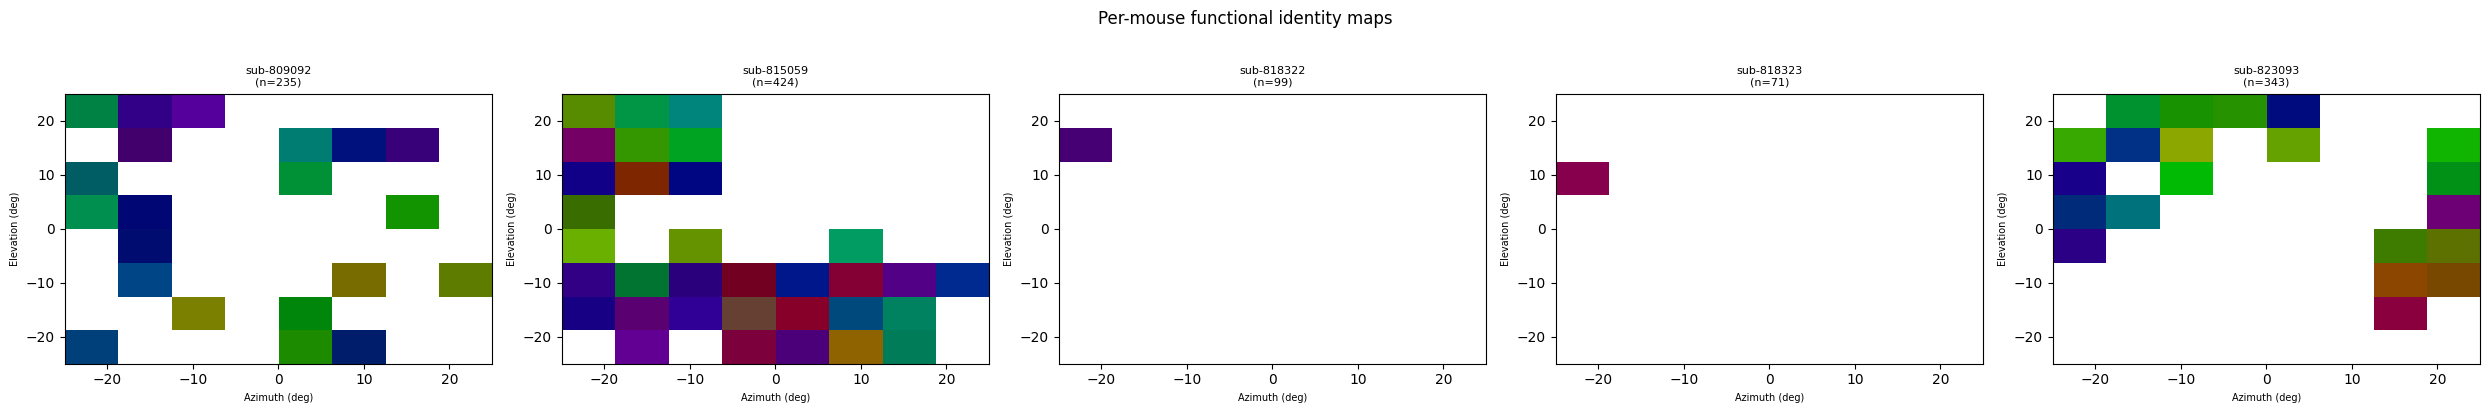

In [66]:
# ── Per-mouse visual field maps ───────────────────────────────────────────────
unique_mice = df_v['mouse'].unique()
n_mice      = len(unique_mice)

fig, axes = plt.subplots(1, n_mice, figsize=(5 * n_mice, 4))

for ax, mouse in zip(axes, unique_mice):
    mask_m      = df_v['mouse'].values == mouse
    rf_x_m      = rf_x[mask_m]
    rf_y_m      = rf_y[mask_m]
    colors_m    = colors_v[mask_m]

    color_map_m = np.full((N_BINS, N_BINS, 3), np.nan)
    count_map_m = np.zeros((N_BINS, N_BINS))

    for i in range(N_BINS):
        for j in range(N_BINS):
            mask = (
                (rf_x_m >= x_bins[i]) & (rf_x_m < x_bins[i+1]) &
                (rf_y_m >= y_bins[j]) & (rf_y_m < y_bins[j+1])
            )
            if mask.sum() > 0:
                color_map_m[j, i] = colors_m[mask].mean(axis=0)
                count_map_m[j, i] = mask.sum()

    color_map_m[count_map_m < 5] = np.nan

    # Boost saturation
    color_map_m_vivid = color_map_m.copy()
    for i in range(N_BINS):
        for j in range(N_BINS):
            if not np.isnan(color_map_m[j, i, 0]):
                h, s, v = colorsys.rgb_to_hsv(*color_map_m[j, i])
                color_map_m_vivid[j, i] = mcolors.hsv_to_rgb([h, min(s * 10, 1.0), v])

    display_m = np.where(np.isnan(color_map_m_vivid), 1.0, color_map_m_vivid)
    ax.imshow(display_m, origin='lower',
              extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
              aspect='auto')
    ax.set_title(f"{mouse}\n(n={mask_m.sum()})", fontsize=8)
    ax.set_xlabel("Azimuth (deg)", fontsize=7)
    ax.set_ylabel("Elevation (deg)", fontsize=7)

plt.suptitle("Per-mouse functional identity maps", y=1.02)
plt.tight_layout()
plt.savefig(data_dir / "visual_field_map_per_mouse.png", dpi=150, bbox_inches='tight')
plt.show()

## Moran's I

Running Moran's I per cluster...
  Cluster  0 (n= 113): I=-0.0068, z=-1.01, p=0.860
  Cluster  1 (n= 411): I=0.0175, z=2.79, p=0.020
  Cluster  2 (n= 190): I=0.0298, z=4.52, p=0.010
  Cluster  3 (n= 127): I=0.0035, z=0.70, p=0.250
  Cluster 4: too few neurons, skipping
  Cluster 5: too few neurons, skipping
  Cluster  6 (n= 109): I=-0.0102, z=-1.39, p=0.900
  Cluster  7 (n=  77): I=-0.0052, z=-0.67, p=0.720
  Cluster  8 (n=  95): I=-0.0133, z=-2.04, p=0.980
  Cluster  9 (n=  99): I=-0.0049, z=-0.73, p=0.760
  Cluster 10 (n= 233): I=0.0266, z=3.77, p=0.010
  Cluster 11 (n= 248): I=-0.0037, z=-0.45, p=0.670
  Cluster 12 (n=  94): I=0.0081, z=1.37, p=0.100
  Cluster 13 (n= 578): I=0.0285, z=4.11, p=0.010
  Cluster 14: too few neurons, skipping
  Cluster 15 (n= 122): I=-0.0102, z=-1.34, p=0.920
  Cluster 16 (n= 103): I=0.0057, z=0.71, p=0.240
  Cluster 17 (n=  58): I=0.0022, z=0.45, p=0.280
  Cluster 18 (n= 140): I=-0.0017, z=-0.36, p=0.680
  Cluster 19 (n=  92): I=0.0077, z=1.00, p=0.130


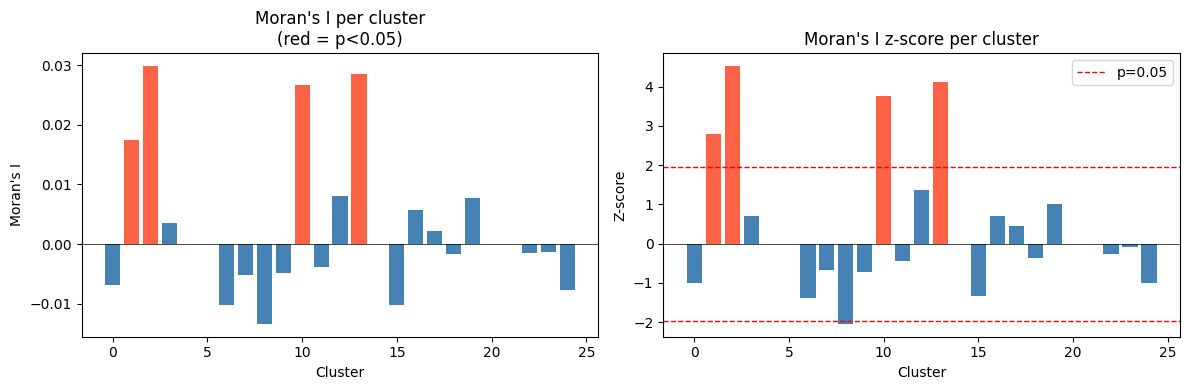


Significant clusters: 4 / 20
    cluster    n  morans_I   z_score  p_value
1         1  411  0.017532  2.790842     0.02
2         2  190  0.029837  4.524345     0.01
8        10  233  0.026645  3.771094     0.01
11       13  578  0.028504  4.105379     0.01


In [80]:
from scipy.spatial.distance import cdist

def morans_i(values, coords, k=10):
    """
    Compute Moran's I using k-nearest spatial neighbors.
    values: (n,) array of the variable to test
    coords: (n, 2) array of spatial coordinates
    k:      number of nearest neighbors to use
    """
    n = len(values)
    
    # Build spatial weight matrix using k nearest neighbors
    dists = cdist(coords, coords, metric='euclidean')
    np.fill_diagonal(dists, np.inf)
    
    W = np.zeros((n, n))
    for i in range(n):
        nn_idx = np.argsort(dists[i])[:k]
        W[i, nn_idx] = 1.0
    
    # Row-normalize
    W = W / W.sum(axis=1, keepdims=True)
    
    # Compute Moran's I
    z = values - values.mean()
    numerator   = n * (W * np.outer(z, z)).sum()
    denominator = (z ** 2).sum() * W.sum()
    I = numerator / denominator
    
    return I

def morans_i_permutation_test(values, coords, k=10, n_perm=999):
    """Permutation test for Moran's I significance."""
    I_obs = morans_i(values, coords, k=k)
    
    I_perm = np.array([
        morans_i(np.random.permutation(values), coords, k=k)
        for _ in range(n_perm)
    ])
    
    p_value = (np.sum(I_perm >= I_obs) + 1) / (n_perm + 1)
    z_score = (I_obs - I_perm.mean()) / I_perm.std()
    
    return I_obs, p_value, z_score, I_perm

# ── Run Moran's I per cluster ──────────────────────────────────────────────────
print("Running Moran's I per cluster...")

# Use valid RF neurons with their retinotopic coordinates
valid    = df['rf_center_x'].notna() & df['rf_center_y'].notna()
df_v     = df[valid].reset_index(drop=True)
coords   = df_v[['rf_center_x', 'rf_center_y']].values

# Need GMM labels — use the ones already in unit_info_with_rf or recompute
# If gmm_label column exists:
if 'gmm_label' not in df_v.columns:
    print("No gmm_label found — run GMM first and save labels to df")
else:
    n_clusters = df_v['gmm_label'].nunique()
    results    = []

    for k in range(n_clusters):
        # Binary: is this neuron in cluster k?
        binary = (df_v['gmm_label'].values == k).astype(float)
        
        if binary.sum() < 20:
            print(f"  Cluster {k}: too few neurons, skipping")
            continue
        
        I_obs, p_val, z_sc, I_perm = morans_i_permutation_test(
            binary, coords, k=10, n_perm=99
        )
        results.append({
            'cluster':  k,
            'n':        int(binary.sum()),
            'morans_I': I_obs,
            'z_score':  z_sc,
            'p_value':  p_val,
        })
        print(f"  Cluster {k:2d} (n={int(binary.sum()):4d}): I={I_obs:.4f}, z={z_sc:.2f}, p={p_val:.3f}")

    results_df = pd.DataFrame(results)
    results_df.to_csv(data_dir / "morans_i_results.csv", index=False)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    colors_bar = ['tomato' if p < 0.05 else 'steelblue' for p in results_df['p_value']]
    ax.bar(results_df['cluster'], results_df['morans_I'], color=colors_bar)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Moran's I")
    ax.set_title("Moran's I per cluster\n(red = p<0.05)")

    ax = axes[1]
    ax.bar(results_df['cluster'], results_df['z_score'], color=colors_bar)
    ax.axhline(1.96,  color='r', lw=1, linestyle='--', label='p=0.05')
    ax.axhline(-1.96, color='r', lw=1, linestyle='--')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Z-score")
    ax.set_title("Moran's I z-score per cluster")
    ax.legend()

    plt.tight_layout()
    plt.savefig(data_dir / "morans_i_per_cluster.png", dpi=150)
    plt.show()

    n_sig = (results_df['p_value'] < 0.05).sum()
    print(f"\nSignificant clusters: {n_sig} / {len(results_df)}")
    print(results_df[results_df['p_value'] < 0.05])

In [81]:
# Check mouse composition of significant clusters
for k in [1, 2, 10, 13]:
    mask = df_v['gmm_label'].values == k
    print(f"\nCluster {k} (n={mask.sum()}):")
    print(df_v[mask]['mouse'].value_counts())


Cluster 1 (n=411):
sub-823093    132
sub-815059    127
sub-818323     91
sub-818322     50
sub-809092     11
Name: mouse, dtype: int64

Cluster 2 (n=190):
sub-809092    187
sub-823093      2
sub-815059      1
Name: mouse, dtype: int64

Cluster 10 (n=233):
sub-809092    165
sub-823093     32
sub-815059     26
sub-818322      6
sub-818323      4
Name: mouse, dtype: int64

Cluster 13 (n=578):
sub-815059    253
sub-823093    180
sub-818323     64
sub-818322     57
sub-809092     24
Name: mouse, dtype: int64


In [82]:
for k in [1, 13]:
    print(f"\n=== Cluster {k} ===")
    mask_cluster = df_v['gmm_label'].values == k
    
    for mouse in df_v['mouse'].unique():
        mask_mouse  = df_v['mouse'].values == mouse
        mask_both   = mask_cluster & mask_mouse
        
        if mask_both.sum() < 20:
            continue
        
        coords_m = df_v[mask_mouse][['rf_center_x', 'rf_center_y']].values
        binary_m = mask_cluster[mask_mouse].astype(float)
        
        I_obs, p_val, z_sc, _ = morans_i_permutation_test(
            binary_m, coords_m, k=10, n_perm=99
        )
        print(f"  {mouse} (n={mask_both.sum()}): I={I_obs:.4f}, z={z_sc:.2f}, p={p_val:.3f}")


=== Cluster 1 ===
  sub-815059 (n=127): I=0.0045, z=0.46, p=0.290
  sub-818322 (n=50): I=-0.0228, z=-0.74, p=0.790
  sub-818323 (n=91): I=-0.0111, z=-0.36, p=0.600
  sub-823093 (n=132): I=0.0404, z=3.18, p=0.010

=== Cluster 13 ===
  sub-809092 (n=24): I=0.0122, z=0.93, p=0.130
  sub-815059 (n=253): I=0.0460, z=3.33, p=0.010
  sub-818322 (n=57): I=-0.0122, z=-0.31, p=0.630
  sub-818323 (n=64): I=-0.0016, z=-0.06, p=0.460
  sub-823093 (n=180): I=-0.0013, z=-0.20, p=0.560
